# Homework — Sessions 1, 2 and 3

**Computer Vision and Speech Recognition · EADA Business School**
Stanislaus Lattorff · MILK10k course project

This notebook is **Part A** of the Sessions 1–3 homework. One section per exercise,
each with the code and the written answer.

Everything reusable lives in the importable package `src/milk10k/` — the same package
Part B's pipeline uses — so nothing is copy-pasted between the notebook and the project
code. The notebook orchestrates and narrates; the package does the work.

**Paths.** There are no absolute paths anywhere. The dataset location comes from a single
place, `milk10k.config`, which reads the environment variable `MILK10K_IMAGES_DIR` if it
is set and otherwise falls back to `data/milk10k/images` inside the repo. See the README.

**Reproducibility.** Every random operation takes its seed from `config.SEED` (= 42).
Restart & Run All reproduces every number below.

## Setup

In [1]:
import sys
from pathlib import Path

# Make the project package importable no matter where the kernel was started.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from milk10k import config, data, labels, plots, preprocessing, splits, transforms

config.apply_style()
config.ensure_project_dirs()

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 40)

print("python  ", sys.version.split()[0])
print("pandas  ", pd.__version__, "| numpy", np.__version__)
def _rel(path):
    """Show a path relative to the repo, so no machine-specific path is printed."""
    try:
        return path.relative_to(config.PROJECT_ROOT)
    except ValueError:
        return path  # MILK10K_IMAGES_DIR points outside the repo

print("data dir", _rel(config.DATA_DIR))
print("images  ", _rel(config.IMG_DIR), "| exists:", config.IMG_DIR.exists())
print("seed    ", config.SEED)

python   3.14.3
pandas   3.0.5 | numpy 2.5.3
data dir data/milk10k
images   data/milk10k/images | exists: True
seed     42


## A1.1 Cross-check the two label files

`metadata.csv` (one row per **image**) and `training_gt.csv` (one row per **lesion**)
come from different parts of the MILK study pipeline, and every later step assumes they
describe the same universe and agree with each other. Below, five of those assumptions
are written as executable checks, run against the real data, and then re-run against
deliberately corrupted copies to show that each check can actually fail. A check that
can only pass is decoration.

In [2]:
meta = data.load_metadata()
gt = data.load_training_gt()

ONEHOT_COLS = [c for c in gt.columns if c != "lesion_id"]

print(f"metadata.csv     {meta.shape[0]:>6,} rows x {meta.shape[1]:>2} cols   "
      f"{meta['isic_id'].nunique():,} images, {meta['lesion_id'].nunique():,} lesions")
print(f"training_gt.csv  {gt.shape[0]:>6,} rows x {gt.shape[1]:>2} cols   "
      f"{gt['lesion_id'].nunique():,} lesions, {len(ONEHOT_COLS)} one-hot columns")
print(f"one-hot columns: {ONEHOT_COLS}")

# The grain is the thing to get right before anything else: a per-image row count of
# 10,480 next to a per-lesion row count of 5,240 is the whole reason this cross-check
# exists. Assert the identifiers are what we think they are, not just the shapes.
assert meta["isic_id"].is_unique, "isic_id repeats — metadata is not one row per image"
assert gt["lesion_id"].is_unique, "lesion_id repeats — gt is not one row per lesion"
assert set(ONEHOT_COLS) == set(config.STRETCH_LABELS), "unexpected one-hot columns"

metadata.csv     10,480 rows x 17 cols   10,480 images, 5,240 lesions
training_gt.csv   5,240 rows x 12 cols   5,240 lesions, 11 one-hot columns
one-hot columns: ['AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']


### The five checks

Each check is a function of `(meta, gt)` returning `(passed, detail)`. Writing them as
functions rather than inline assertions is what makes the corruption test in the last
cell possible — the same code has to be runnable on data we know is broken.

In [3]:
# Fields that describe the lesion, not the photograph, and must therefore be identical
# on both of a lesion's two rows. image_type is deliberately absent: it is the one field
# that is *supposed* to differ.
LESION_CONSTANT_FIELDS = [
    "age_approx", "sex", "anatom_site_general",
    "diagnosis_1", "diagnosis_2", "diagnosis_3", "diagnosis_4",
]


def lesion_view(meta_df, gt_df):
    """One row per lesion: 11-class code from gt, diagnosis_1 from metadata.

    An inner join, so a lesion-id mismatch shows up as a shorter table here rather
    than as a NaN that quietly propagates into the crosstab.
    """
    dx = pd.DataFrame({
        "lesion_id": gt_df["lesion_id"],
        "dx": gt_df[ONEHOT_COLS].idxmax(axis=1),
    })
    primary = meta_df[["lesion_id", "diagnosis_1"]].drop_duplicates(subset="lesion_id")
    return dx.merge(primary, on="lesion_id", how="inner", validate="one_to_one")


def code_crosstab(meta_df, gt_df):
    """11-class code (rows) x diagnosis_1 (columns), counted in lesions."""
    view = lesion_view(meta_df, gt_df)
    ct = pd.crosstab(view["dx"], view["diagnosis_1"])
    present = [c for c in config.PRIMARY_LABELS if c in ct.columns]
    assert set(ct.columns) == set(present), f"unexpected diagnosis_1 values: {list(ct.columns)}"
    return ct.reindex(columns=config.PRIMARY_LABELS, fill_value=0)


def parents_per_child(meta_df, child, parent):
    """How many distinct `parent` values each non-null `child` value appears under."""
    pairs = meta_df[[child, parent]].dropna(subset=[child])
    return pairs.groupby(child, dropna=True)[parent].nunique(dropna=False)


def check_a_lesion_ids_match(meta_df, gt_df):
    in_meta, in_gt = set(meta_df["lesion_id"]), set(gt_df["lesion_id"])
    only_meta, only_gt = in_meta - in_gt, in_gt - in_meta
    return (not only_meta and not only_gt,
            f"{len(in_meta):,} in metadata, {len(in_gt):,} in gt; "
            f"{len(only_meta)} only in metadata, {len(only_gt)} only in gt")


def check_b_one_positive(meta_df, gt_df):
    positives = gt_df[ONEHOT_COLS].sum(axis=1)
    counts = positives.value_counts().sort_index()
    bad = int((positives != 1).sum())
    return (bad == 0,
            f"{len(gt_df) - bad:,}/{len(gt_df):,} rows have exactly one positive; "
            "positives-per-row seen: "
            + ", ".join(f"{int(k)} positive x {int(v):,} rows" for k, v in counts.items()))


def check_c_code_to_diagnosis_1(meta_df, gt_df):
    ct = code_crosstab(meta_df, gt_df)
    ambiguous = ct.index[ct.gt(0).sum(axis=1) > 1].tolist()
    n_affected = int(ct.loc[ambiguous].to_numpy().sum()) if ambiguous else 0
    return (not ambiguous,
            f"{len(ct) - len(ambiguous)}/{len(ct)} codes map to one diagnosis_1; "
            f"straddling: {ambiguous or 'none'} ({n_affected:,} lesions)")


def check_d_taxonomy_nests(meta_df, gt_df):
    details, n_bad_total = [], 0
    for child, parent in [("diagnosis_3", "diagnosis_2"), ("diagnosis_2", "diagnosis_1")]:
        n_parents = parents_per_child(meta_df, child, parent)
        n_bad = int((n_parents > 1).sum())
        n_bad_total += n_bad
        details.append(f"{n_bad}/{len(n_parents)} {child} values have >1 {parent}")
    return n_bad_total == 0, "; ".join(details)


def check_e_pair_agreement(meta_df, gt_df):
    varying = {
        col: int((meta_df.groupby("lesion_id")[col].nunique(dropna=False) > 1).sum())
        for col in LESION_CONSTANT_FIELDS
    }
    offenders = {c: n for c, n in varying.items() if n > 0}
    return (not offenders,
            f"{len(LESION_CONSTANT_FIELDS)} fields checked across "
            f"{meta_df['lesion_id'].nunique():,} lesions; disagreeing: {offenders or 'none'}")


CHECKS = [
    ("a", "lesion_id sets identical in metadata.csv and training_gt.csv", check_a_lesion_ids_match),
    ("b", "exactly one positive class per lesion in the one-hot", check_b_one_positive),
    ("c", "each 11-class code maps to exactly one diagnosis_1", check_c_code_to_diagnosis_1),
    ("d", "diagnosis_3 -> diagnosis_2 -> diagnosis_1 each nest cleanly", check_d_taxonomy_nests),
    ("e", "a lesion's two images agree on age, sex, site and diagnosis", check_e_pair_agreement),
]


def run_checks(meta_df, gt_df):
    rows = [(cid, question, *fn(meta_df, gt_df)) for cid, question, fn in CHECKS]
    out = pd.DataFrame(rows, columns=["id", "check", "passed", "detail"])
    out.insert(3, "result", np.where(out["passed"], "PASS", "VIOLATION"))
    return out.drop(columns="passed")

In [4]:
summary = run_checks(meta, gt)
print(summary.to_string(index=False))

n_violations = int((summary["result"] == "VIOLATION").sum())
print(f"\n{len(summary) - n_violations}/{len(summary)} checks pass, {n_violations} violation(s).")

# (a), (b), (d) and (e) are hard requirements: if any of them failed the dataset would be
# unusable as it stands, so they are asserted rather than merely reported.
must_pass = summary[summary["id"].isin(["a", "b", "d", "e"])]
assert (must_pass["result"] == "PASS").all(), f"structural failure:\n{must_pass}"

# (c) is different. It is *expected* to report a violation, and the violation is the
# finding of this exercise — so pin down exactly which code straddles, and fail loudly
# if that ever changes.
assert summary.loc[summary["id"] == "c", "result"].item() == "VIOLATION"

id                                                        check    result                                                                                      detail
 a lesion_id sets identical in metadata.csv and training_gt.csv      PASS                            5,240 in metadata, 5,240 in gt; 0 only in metadata, 0 only in gt
 b         exactly one positive class per lesion in the one-hot      PASS 5,240/5,240 rows have exactly one positive; positives-per-row seen: 1 positive x 5,240 rows
 c           each 11-class code maps to exactly one diagnosis_1 VIOLATION                     10/11 codes map to one diagnosis_1; straddling: ['AKIEC'] (303 lesions)
 d  diagnosis_3 -> diagnosis_2 -> diagnosis_1 each nest cleanly      PASS    0/27 diagnosis_3 values have >1 diagnosis_2; 0/19 diagnosis_2 values have >1 diagnosis_1
 e  a lesion's two images agree on age, sex, site and diagnosis      PASS                                    7 fields checked across 5,240 lesions; disagreeing: none

4/5

### (c) in detail — where the 11-class code does not determine `diagnosis_1`

In [5]:
ct = code_crosstab(meta, gt)
n_lesions = int(ct.to_numpy().sum())

detail = ct.copy()
detail["total"] = ct.sum(axis=1)
detail["maps_to"] = ct.gt(0).apply(lambda row: " + ".join(ct.columns[row.to_numpy()]), axis=1)
print(detail.sort_values("total", ascending=False).to_string())

ambiguous = ct.index[ct.gt(0).sum(axis=1) > 1].tolist()
assert ambiguous == ["AKIEC"], f"the set of straddling codes changed: {ambiguous}"

print(f"\nCodes that do NOT map to exactly one diagnosis_1: {ambiguous}")
n_affected = 0
for code in ambiguous:
    row = ct.loc[code]
    n_affected += int(row.sum())
    parts = ", ".join(f"{cls} {int(n):,}" for cls, n in row.items() if n > 0)
    print(f"  {code} ({config.DIAGNOSIS_CODES[code]}): {parts}")
print(f"  affected lesions: {n_affected:,} of {n_lesions:,} "
      f"({n_affected / n_lesions * 100:.1f}% of the dataset)")

# The other direction is the more alarming one: which diagnosis_1 values can only be
# reached from a single code? If a class has exactly one source code, the two label
# schemes are not independent views of the lesion — one is nearly a relabelling of the other.
print("\nReachability, diagnosis_1 <- 11-class code:")
for cls in ct.columns:
    sources = ct.index[ct[cls] > 0].tolist()
    print(f"  {cls:<14} {ct[cls].sum():>5,} lesions from {len(sources)} code(s): {sources}")

diagnosis_1  Benign  Indeterminate  Malignant  total                    maps_to
dx                                                                             
BCC               0              0       2522   2522                  Malignant
NV              746              0          0    746                     Benign
BKL             544              0          0    544                     Benign
SCCKA             0              0        473    473                  Malignant
MEL               0              0        450    450                  Malignant
AKIEC             0            123        180    303  Indeterminate + Malignant
DF               52              0          0     52                     Benign
INF              50              0          0     50                     Benign
VASC             47              0          0     47                     Benign
BEN_OTH          44              0          0     44                     Benign
MAL_OTH           0              0      

### (d) in detail — does the diagnosis taxonomy nest?

In [6]:
for child, parent in [("diagnosis_3", "diagnosis_2"), ("diagnosis_2", "diagnosis_1")]:
    n_parents = parents_per_child(meta, child, parent)
    bad = n_parents[n_parents > 1]
    print(f"{child:<12} -> {parent:<12} "
          f"{len(n_parents):>3} distinct {child} values, "
          f"{len(bad)} with more than one {parent}")
    if len(bad):
        print(bad.to_string())

# diagnosis_4 is not part of the brief's check but is the same taxonomy one level deeper,
# so it costs nothing to confirm the pattern holds all the way down.
n_parents_4 = parents_per_child(meta, "diagnosis_4", "diagnosis_3")
print(f"{'diagnosis_4':<12} -> {'diagnosis_3':<12} "
      f"{len(n_parents_4):>3} distinct diagnosis_4 values, "
      f"{int((n_parents_4 > 1).sum())} with more than one diagnosis_3")

diagnosis_3  -> diagnosis_2   27 distinct diagnosis_3 values, 0 with more than one diagnosis_2
diagnosis_2  -> diagnosis_1   19 distinct diagnosis_2 values, 0 with more than one diagnosis_1
diagnosis_4  -> diagnosis_3   15 distinct diagnosis_4 values, 0 with more than one diagnosis_3


### Would these checks notice if the data were broken?

Each check is now re-run on a copy of the data with one targeted defect injected. A
check that does not change its verdict on the corrupted copy is not testing anything.

In [7]:
def corrupt_a(meta_df, gt_df):
    """Drop one lesion from the ground truth — labels and images no longer line up."""
    return meta_df, gt_df.drop(index=gt_df.index[0])


def corrupt_b(meta_df, gt_df):
    """Add a second positive to one one-hot row — the lesion becomes multi-label."""
    broken = gt_df.copy()
    first = broken.index[0]
    already = broken.loc[first, ONEHOT_COLS].idxmax()
    other = next(c for c in ONEHOT_COLS if c != already)
    broken.loc[first, other] = 1
    return meta_df, broken


def corrupt_c(meta_df, gt_df):
    """Flip one NV lesion to Malignant — a second code starts straddling diagnosis_1."""
    broken = meta_df.copy()
    nv = lesion_view(meta_df, gt_df).query("dx == 'NV'")["lesion_id"].iloc[0]
    broken.loc[broken["lesion_id"] == nv, "diagnosis_1"] = "Malignant"
    return broken, gt_df


def corrupt_d(meta_df, gt_df):
    """Re-parent one row — a diagnosis_3 value now sits under two diagnosis_2 values."""
    broken = meta_df.copy()
    row = broken.index[broken["diagnosis_3"].notna()][0]
    broken.loc[row, "diagnosis_2"] = "Wrong parent"
    return broken, gt_df


def corrupt_e(meta_df, gt_df):
    """Change the age on one image only — a lesion now disagrees with itself."""
    broken = meta_df.copy()
    row = broken.index[0]
    broken.loc[row, "age_approx"] = broken.loc[row, "age_approx"] + 20
    return broken, gt_df


CORRUPTIONS = {"a": corrupt_a, "b": corrupt_b, "c": corrupt_c, "d": corrupt_d, "e": corrupt_e}

rows = []
for cid, question, fn in CHECKS:
    real_passed, real_detail = fn(meta, gt)
    broken_meta, broken_gt = CORRUPTIONS[cid](meta, gt)
    broken_passed, broken_detail = fn(broken_meta, broken_gt)

    # Two ways a check can prove it is alive: flip from pass to fail, or - for (c),
    # which already reports a violation - change what it says about the violation.
    reacted = (not broken_passed) and (broken_detail != real_detail)
    rows.append((cid, CORRUPTIONS[cid].__doc__.splitlines()[0],
                 "PASS" if real_passed else "VIOLATION",
                 "PASS" if broken_passed else "VIOLATION",
                 "yes" if reacted else "NO — CHECK IS BLIND"))
    assert reacted, f"check ({cid}) did not react to its corruption: {broken_detail}"

control = pd.DataFrame(rows, columns=["id", "injected defect", "on real data",
                                      "on corrupted copy", "detected"])
print(control.to_string(index=False))

# (c) already reports a violation on the real data, so "it still says VIOLATION" would
# prove nothing. What it has to show is that the verdict tracks the data.
print("\n(c) is the one check that already fails, so its evidence is the change in detail:")
print(f"   real data     : {check_c_code_to_diagnosis_1(meta, gt)[1]}")
print(f"   corrupted copy: {check_c_code_to_diagnosis_1(*corrupt_c(meta, gt))[1]}")

id                                                                injected defect on real data on corrupted copy detected
 a   Drop one lesion from the ground truth — labels and images no longer line up.         PASS         VIOLATION      yes
 b     Add a second positive to one one-hot row — the lesion becomes multi-label.         PASS         VIOLATION      yes
 c Flip one NV lesion to Malignant — a second code starts straddling diagnosis_1.    VIOLATION         VIOLATION      yes
 d Re-parent one row — a diagnosis_3 value now sits under two diagnosis_2 values.         PASS         VIOLATION      yes
 e         Change the age on one image only — a lesion now disagrees with itself.         PASS         VIOLATION      yes

(c) is the one check that already fails, so its evidence is the change in detail:


   real data     : 10/11 codes map to one diagnosis_1; straddling: ['AKIEC'] (303 lesions)


   corrupted copy: 9/11 codes map to one diagnosis_1; straddling: ['AKIEC', 'NV'] (1,049 lesions)


### Cross-check against the project package

The same structural claims are implemented inside `milk10k.quality` and
`milk10k.labels`, which is what the pipeline and the data-quality report use. Two
independent implementations agreeing is worth more than one implementation asserting.

In [8]:
from milk10k import quality

pkg_checks = quality.label_consistency_checks(df=meta, gt=gt)
print(pkg_checks.to_string(index=False))

pkg_table = labels.code_to_primary_table(gt=gt, meta=meta)
pkg_ambiguous = pkg_table.loc[pkg_table["ambiguous"], "dx"].tolist()
print(f"\nmilk10k.labels says the straddling codes are: {pkg_ambiguous}")
assert pkg_ambiguous == ambiguous, "the notebook and the package disagree about ambiguity"

# The package's crosstab must contain the same numbers this section computed by hand.
pkg_counts = pkg_table.set_index("dx")[config.PRIMARY_LABELS].reindex(index=ct.index)
assert (pkg_counts.to_numpy() == ct.to_numpy()).all(), "counts differ from the package"
print("Package and notebook agree on all "
      f"{ct.shape[0]} x {ct.shape[1]} code x diagnosis_1 counts.")

                                                  check  passed                                                                      detail
                      Every lesion has exactly 2 images    True                                                       5,240 / 5,240 lesions
         Each lesion has exactly one image of each type    True 5,240 / 5,240 lesions; types present: ['clinical: close-up', 'dermoscopic']
   lesion_id sets identical in metadata and training_gt    True       5,240 metadata / 5,240 ground-truth; 0 only in metadata, 0 only in gt
   Exactly one positive class per lesion in the one-hot    True                                  5,240 / 5,240 rows; positives per row: [1]
              'diagnosis_1' is constant within a lesion    True                                          0 lesions with more than one value
               'age_approx' is constant within a lesion    True                                          0 lesions with more than one value
                    

**Answer.** Ten of the eleven codes map to a single `diagnosis_1`; AKIEC is the sole
exception, splitting 123 Indeterminate against 180 Malignant, and — the sharper half of
the finding — all 123 Indeterminate lesions in the dataset are AKIEC, so that class has
exactly one source code. `diagnosis_1` therefore cannot be derived from an 11-class
prediction: for those 303 lesions, 5.8% of the 5,240, the code leaves the coarse label
undetermined, and they are the hardest cases precisely because AKIEC bundles actinic
keratosis with squamous cell carcinoma in situ, a genuine biological continuum rather
than a data-entry bug, which is why this project trains the two targets separately
instead of deriving one from the other. On any new medical dataset I would repeat all
five checks before training: ID-set equality between the label file and the image file,
one label per modelling unit, the fine-label-to-coarse-label crosstab, the nesting of
every taxonomy level, and the within-group constancy of every attribute I intend to
aggregate over. The most dangerous failure is the silent label corruption of (b) and
(e): a one-hot row with two positives, or a lesion whose two photographs carry
different diagnoses, trains the network on a flat contradiction with no error message
anywhere — `idxmax` simply returns the alphabetically first class, the loss still goes
down, and the damage only surfaces as unexplained ceiling error much later. A mismatch
in (a) is the next worst, because a lesion present in one file and missing from the
other changes the grouping key rather than crashing, and a broken grouping key puts one
photograph of a lesion in train and the other in test — leakage that inflates every
number in the report.

## A1.2 Ask the data five questions

Five questions that a clinician or a modeller would actually ask, each answered with a
few lines of pandas. The point is not the pandas — it is that the answers change what
the model gets built on. Two of them (Q4, Q5) turn into design decisions later.

**Grain matters.** The dataset has two row units and mixing them silently doubles or
halves every count. Q1, Q3 and Q4 are about lesions and patients, so they use the
**lesion** table (5,240 rows). Q2 asks for a "percentage of images", so it uses the
**image** table (10,480 rows). Q5 is stated at **lesion** grain, because
`diagnosis_confirm_type` describes the biopsy of a lesion, not a photograph.

In [9]:
# Both grains, built once from the package rather than re-derived per question.
meta = data.load_metadata()                 # one row per IMAGE  (10,480)
lesions = data.build_lesion_table()         # one row per LESION (5,240)

# The 11-class code lives at lesion grain; broadcasting it onto the images is what
# makes an image-grain question like Q2 answerable at all.
images = meta.merge(labels.lesion_labels(), on="lesion_id",
                    how="left", validate="many_to_one")

assert len(meta) == 10_480 and len(lesions) == 5_240
assert images["dx"].notna().all(), "an image was left without an 11-class code"
assert (meta.groupby("lesion_id")["image_type"].nunique() == 2).all()

print(f"image grain : {len(images):,} rows")
print(f"lesion grain: {len(lesions):,} rows")

image grain : 10,480 rows
lesion grain: 5,240 rows


### Q1 — BCC lesions in patients aged 70+ on the head/neck

Lesion grain: one basal cell carcinoma is one lesion, however many photos of it exist.

In [10]:
q1 = lesions[(lesions["dx"] == "BCC")
             & (lesions["age"] >= 70)
             & (lesions["site"] == "head/neck")]

n_bcc = int((lesions["dx"] == "BCC").sum())
print(f"BCC lesions, age >= 70, head/neck: {len(q1):,} "
      f"({100 * len(q1) / n_bcc:.1f}% of all {n_bcc:,} BCC lesions)")
print(f"excluded by the filter because the field is missing: "
      f"{int(lesions['age'].isna().sum())} lesions without age, "
      f"{int(lesions['site'].isna().sum()):,} without site")

BCC lesions, age >= 70, head/neck: 380 (15.1% of all 2,522 BCC lesions)
excluded by the filter because the field is missing: 20 lesions without age, 1,956 without site


**Answer.** 380 lesions — 15.1% of the 2,522 BCC lesions in the dataset. The filter is
deliberately strict: `age >= 70` drops the 20 lesions with no recorded age, and
`site == "head/neck"` drops the 1,956 with no recorded site (both printed above), so 380 is a floor, not an
estimate of how many such lesions exist.

### Q2 — which class has the highest share of "altered" images?

Image grain, because `image_manipulation` is a property of a photograph, not of a lesion.

In [11]:
images["is_altered"] = images["image_manipulation"].eq("altered")

altered = images.groupby("dx")["is_altered"].agg(n_images="size", n_altered="sum")
altered["pct_altered"] = 100 * altered["n_altered"] / altered["n_images"]
altered = altered.sort_values("pct_altered", ascending=False)

# Counts stay next to the rate: a rate over a tiny denominator is not a finding.
print(altered.round(2).to_string())
top = altered.index[0]
print(f"\nHighest: {top} at {altered.loc[top, 'pct_altered']:.2f}% "
      f"({altered.loc[top, 'n_altered']} of {altered.loc[top, 'n_images']} images)")

         n_images  n_altered  pct_altered
dx                                       
BEN_OTH        88         16        18.18
INF           100          8         8.00
AKIEC         606         43         7.10
MEL           900         57         6.33
VASC           94          4         4.26
NV           1492         60         4.02
BKL          1088         43         3.95
DF            104          2         1.92
BCC          5044         92         1.82
SCCKA         946         10         1.06
MAL_OTH        18          0         0.00

Highest: BEN_OTH at 18.18% (16 of 88 images)


**Answer.** BEN_OTH, at 18.18% — but that is 16 altered images out of only 88, so the
rate is built on 16 observations and would swing by ~1 pp if a single image were
reclassified. The runners-up are INF 8.00% (8/100), AKIEC 7.10% (43/606) and MEL 6.33%
(57/900); MEL is the first entry with a denominator large enough to take at face value.
The honest reading is that the top two (BEN_OTH, INF, both under 50 lesions) sit there
mostly because small denominators are volatile — the rarest class of all, MAL_OTH, sits
at 0/18 for the same reason — not because those lesions are systematically retouched.

### Q3 — youngest and oldest melanoma patient

Lesion grain: the question is about patients, and ages are recorded per lesion.

In [12]:
mel = lesions[lesions["dx"] == "MEL"]
youngest, oldest = mel["age"].min(), mel["age"].max()

print(f"MEL lesions: {len(mel):,} | missing age: {int(mel['age'].isna().sum())}")
print(f"youngest {youngest:.0f}  oldest {oldest:.0f}  gap {oldest - youngest:.0f} years")

MEL lesions: 450 | missing age: 0
youngest 20  oldest 85  gap 65 years


**Answer.** Youngest 20, oldest 85, a 65-year gap, with zero missing ages among the 450
melanoma lesions. `age_approx` is binned in fives, so these are bin labels rather than
exact ages. A 65-year span means age carries little discriminative power for melanoma on
its own — it spreads across essentially the whole adult range of the dataset.

### Q4 — is a missing `anatom_site_general` informative?

3,912 of 10,480 image rows have no recorded site. If that missingness were random, the
class mix of lesions with and without a site would look the same. Lesion grain.

In [13]:
has_site = lesions["site"].notna()

site_cmp = pd.DataFrame({
    "with_site_pct": lesions.loc[has_site, "dx"].value_counts(normalize=True) * 100,
    "without_site_pct": lesions.loc[~has_site, "dx"].value_counts(normalize=True) * 100,
}).fillna(0)
site_cmp["delta_pp"] = site_cmp["without_site_pct"] - site_cmp["with_site_pct"]
site_cmp = site_cmp.reindex(site_cmp["delta_pp"].abs().sort_values(ascending=False).index)

print(f"n = {int(has_site.sum()):,} with a site / {int((~has_site).sum()):,} without\n")
print(site_cmp.round(2).to_string())

benign_by_site = pd.crosstab(has_site.map({True: "with site", False: "without site"}),
                             lesions["diagnosis_1"], normalize="index") * 100
print("\ndiagnosis_1 mix (% of lesions):")
print(benign_by_site.round(1).to_string())

n = 3,284 with a site / 1,956 without

         with_site_pct  without_site_pct  delta_pp
dx                                                
NV               10.14             21.11     10.97
SCCKA            12.70              2.86     -9.83
AKIEC             8.01              2.04     -5.96
MEL               7.16             10.99      3.84
BCC              47.41             49.34      1.92
DF                1.31              0.46     -0.85
BKL              10.57             10.07     -0.49
VASC              0.73              1.18      0.45
MAL_OTH           0.09              0.31      0.22
INF               1.00              0.87     -0.14
BEN_OTH           0.88              0.77     -0.12

diagnosis_1 mix (% of lesions):
diagnosis_1   Benign  Indeterminate  Malignant
site                                          
with site       24.6            3.5       71.8
without site    34.5            0.4       65.2


**Answer.** Not random. NV moves the most: 10.14% of lesions with a recorded site versus
21.11% of those without, **+10.97 pp** — nevi are more than twice as common in the
no-site group. The keratinocyte cancers move the other way (SCCKA −9.83 pp, AKIEC
−5.96 pp), and MEL is +3.84 pp. That pattern is clinically coherent: the lesions that
get a site recorded are disproportionately the sun-damage cancers that cluster on the
head and neck, while a nevus is photographed and filed without the site being typed in.

Two consequences for the pipeline. First, "unknown site" is itself a weak predictor, so
it must be kept as an explicit category — imputing it to the modal site would destroy
real signal and invent a body location that was never observed. Second, it must never be
treated as a neutral default, because it is not: it leans benign (34.5% Benign without a
site versus 24.6% with one, printed above).

### Q5 — malignancy rate by `diagnosis_confirm_type`

Lesion grain. The confirmation type is constant across a lesion's two images, which is
asserted below before collapsing.

In [14]:
confirm_varies = meta.groupby("lesion_id")["diagnosis_confirm_type"].nunique(dropna=False)
assert (confirm_varies == 1).all(), "confirmation type disagrees within a lesion"

lesions_c = lesions.merge(
    meta.groupby("lesion_id", as_index=False)["diagnosis_confirm_type"].first(),
    on="lesion_id", how="left", validate="one_to_one",
)

confirm = pd.crosstab(lesions_c["diagnosis_confirm_type"], lesions_c["diagnosis_1"],
                      normalize="index") * 100
confirm["n_lesions"] = lesions_c["diagnosis_confirm_type"].value_counts()

print(confirm.round(1).to_string())
print(f"\nwhole dataset: {100 * (lesions['diagnosis_1'] == 'Malignant').mean():.1f}% Malignant")

diagnosis_1                             Benign  Indeterminate  Malignant  n_lesions
diagnosis_confirm_type                                                             
histopathology                            25.7            2.0       72.3       5016
single contributor clinical assessment    87.1           10.7        2.2        224

whole dataset: 69.4% Malignant


**Answer.** Histopathology-confirmed lesions are 72.3% Malignant; lesions confirmed by a
single contributor's clinical assessment are 2.2% Malignant (87.1% Benign, 10.7%
Indeterminate). That is a 70-point gap across 5,016 versus 224 lesions.

The confirmation type is not a property of the skin — it records the decision to biopsy,
and that decision was driven by the clinician's suspicion. Anything alarming enough to
cut out went to pathology; anything obviously benign was signed off by eye. So the field
is a direct readout of prior suspicion, which explains two things:

- **Why the dataset is 69.4% Malignant.** It is a collection of biopsied lesions, not a
  sample of skin. Real-world prevalence in a dermatology clinic is nothing like this, so
  any accuracy or calibration number from this data describes a pre-filtered population
  and cannot be quoted as clinic performance.
- **Why `diagnosis_confirm_type` is a textbook leaky feature.** It sits downstream of the
  label and does not exist at prediction time — a model that sees it is reading the
  clinician's answer, not the image. It is on the `config.LEAKY_COLUMNS` list for exactly
  this reason.

## A1.3 Build a lesion-level table

The dataset ships on two different row grains. `metadata.csv` has one row per
**image**; `training_gt.csv` has one row per **lesion**. Every lesion was
photographed twice — once dermoscopically, once as a clinical close-up — so the
image table is exactly twice as long as the label table.

This exercise collapses the image grain onto the lesion grain and puts both image
ids of a lesion side by side in one row:

`lesion_id, derm_id, clinical_id, diagnosis_1, dx, age, sex, site`

**Why the lesion grain matters.** The lesion is the unit of *prediction* — the
clinical question is "is this mole malignant", not "is this photograph malignant".
It is therefore also the unit of *evaluation*: two predictions on the same lesion
are one decision, not two independent test cases, and scoring them separately
inflates the effective test-set size. Most importantly it is the unit the
train/val/test split must **group** on. The two photos of a lesion show the same
piece of skin on the same patient; putting one in train and the other in test
leaks the answer and buys accuracy that will not survive contact with a new
patient. Holding `derm_id` and `clinical_id` in the same row makes that mistake
structurally impossible — the smallest thing you can move between splits is a
whole lesion.

### The table

`data.build_lesion_table()` does the reshape. The logic lives in the package, not
in this notebook, so the split code and the dataloaders in Part B build the table
the same way rather than re-deriving it.

In [15]:
lesions = data.build_lesion_table()

print("shape:", lesions.shape)
print("columns:", list(lesions.columns))
print()
print(lesions.head().to_string(index=False))

shape: (5240, 8)
columns: ['lesion_id', 'derm_id', 'clinical_id', 'diagnosis_1', 'dx', 'age', 'sex', 'site']

 lesion_id      derm_id  clinical_id diagnosis_1    dx  age    sex            site
IL_0000652 ISIC_4671410 ISIC_8149219   Malignant   BCC 70.0   male       head/neck
IL_0003176 ISIC_5371928 ISIC_3904045   Malignant   BCC 45.0 female       head/neck
IL_0004688 ISIC_3624913 ISIC_0791494   Malignant   BCC 50.0   male lower extremity
IL_0005081 ISIC_5186409 ISIC_5667730   Malignant SCCKA 45.0   male       head/neck
IL_0006177 ISIC_1048297 ISIC_8803389   Malignant   BCC 75.0   male upper extremity


### The assertions, shown rather than hidden

`build_lesion_table()` asserts these internally, but a reader of the notebook
should see them pass on this data rather than take the function's word for it.

In [16]:
checks = {
    "one row per lesion (5,240)": len(lesions) == 5_240,
    "lesion_id is unique": bool(lesions["lesion_id"].is_unique),
    "no missing derm_id": bool(lesions["derm_id"].notna().all()),
    "no missing clinical_id": bool(lesions["clinical_id"].notna().all()),
    # The two id columns must be disjoint and together account for every image:
    # if one photo were filed under both types the pivot would have duplicated it.
    "derm_id and clinical_id disjoint": not set(lesions["derm_id"]) & set(lesions["clinical_id"]),
    "2 x lesions == all images": 2 * len(lesions) == len(data.load_metadata()),
}

for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}  {name}")

assert all(checks.values()), [k for k, v in checks.items() if not v]

PASS  one row per lesion (5,240)
PASS  lesion_id is unique
PASS  no missing derm_id
PASS  no missing clinical_id
PASS  derm_id and clinical_id disjoint
PASS  2 x lesions == all images


### The reshape itself — no loop over rows

The brief requires the two image ids to be brought together with
`pivot`/`unstack`/`groupby`, not with a Python loop. That requirement is the whole
point of the exercise, so it is worth seeing rather than trusting to a function
call. `image_type` is the only thing that distinguishes a lesion's two rows, so it
becomes the **column** axis and `isic_id` becomes the value.

`unstack` is also a correctness check in disguise: it requires
`(lesion_id, image_type)` to be unique, so a lesion with two dermoscopic photos
would raise instead of silently keeping one of them.

In [17]:
meta = data.load_metadata()

# One line does the whole reshape: 10,480 image rows -> 5,240 lesion rows, two id
# columns. No iteration, and no assumption about the order the rows arrive in.
wide = meta.set_index(["lesion_id", "image_type"])["isic_id"].unstack("image_type")
print(wide.columns.tolist())
print(wide.head().to_string())

['clinical: close-up', 'dermoscopic']
image_type clinical: close-up   dermoscopic
lesion_id                                  
IL_0000652       ISIC_8149219  ISIC_4671410
IL_0003176       ISIC_3904045  ISIC_5371928
IL_0004688       ISIC_0791494  ISIC_3624913
IL_0005081       ISIC_5667730  ISIC_5186409
IL_0006177       ISIC_8803389  ISIC_1048297


In [18]:
# Rebuild the full table inline from that reshape, then prove it is the same object
# the package produces. groupby(...).first() is legitimate for the attribute columns
# because age/sex/site/diagnosis do not vary within a lesion (verified by check (e) in A1.1).
inline = wide[["dermoscopic", "clinical: close-up"]]
inline.columns = ["derm_id", "clinical_id"]
inline = inline.rename_axis(columns=None).reset_index()

attrs = (
    meta.groupby("lesion_id", as_index=False)[
        ["diagnosis_1", "age_approx", "sex", "anatom_site_general"]
    ]
    .first()
    .rename(columns={"age_approx": "age", "anatom_site_general": "site"})
)

# The 11-class code comes from the one-hot block in training_gt.csv; collapsing it
# is package logic (it also checks the one-positive-per-row assumption), so reuse it.
dx = data.gt_to_label(data.load_training_gt())[["lesion_id", "label_11"]].rename(
    columns={"label_11": "dx"}
)

inline = (
    inline.merge(attrs, on="lesion_id", how="left", validate="one_to_one")
    .merge(dx, on="lesion_id", how="left", validate="one_to_one")
)[data.LESION_TABLE_COLUMNS]

matches = inline.equals(lesions)
print("inline pivot == data.build_lesion_table():", matches)
assert matches, "the inline reshape disagrees with the package implementation"

inline pivot == data.build_lesion_table(): True


### Save it

The table is written to CSV so that later work loads one fixed set of 5,240
lesions instead of rebuilding it and hoping the result is identical.

In [19]:
path = data.save_lesion_table(lesions)
print("written to:", path.relative_to(config.PROJECT_ROOT))
print("rows on disk:", len(pd.read_csv(path)))

# A3 calls the same data.build_lesion_table() that produced this file's
# contents, so every section splits exactly these 5,240 rows.

written to: artifacts/tables/lesions.csv
rows on disk: 5240


**Answer.** The lesion table has 5,240 rows — one per lesion, exactly half the
10,480 image rows — with columns `lesion_id, derm_id, clinical_id, diagnosis_1,
dx, age, sex, site`. It is built with a single `unstack` on `image_type` plus a
`groupby(...).first()` for the lesion-constant attributes: no Python loop over
rows anywhere. Every lesion has both a dermoscopic and a clinical close-up id
(no missing values in either column), `lesion_id` is unique, and the two id
columns are disjoint and together cover all 10,480 images. The inline reshape
above reproduces `data.build_lesion_table()` exactly (`.equals` is `True`), so
the package version is doing what the notebook claims. The table is saved to
`artifacts/tables/lesions.csv`; A3 obtains the identical table through the same
`data.build_lesion_table()` call and splits it — the split groups on `lesion_id`, which is only safe because both of a lesion's
images live in the same row.

## A1.4 Task framing

Before any modelling decision, the task has to be stated as a problem a clinic would
actually pose. The numbers the framing rests on are printed first, so the specification
below quotes the dataset rather than asserting things about it.

In [20]:
from PIL import Image

from milk10k import imbalance

meta = data.load_metadata()
lesions = data.build_lesion_table()

# The modelling unit is the lesion, not the image — this is what makes that legitimate.
assert len(meta) == 2 * len(lesions), "the two-images-per-lesion assumption broke"

print(f"images : {len(meta):,}")
print(f"lesions: {len(lesions):,}  ({len(meta) // len(lesions)} images each: "
      f"{', '.join(sorted(meta['image_type'].unique()))})")

counts = lesions["diagnosis_1"].value_counts().reindex(config.PRIMARY_LABELS)
share = 100 * counts / len(lesions)
print("\ndiagnosis_1, one row per lesion")
for cls in config.PRIMARY_LABELS:
    print(f"  {cls:<14}{counts[cls]:>6,}{share[cls]:>8.1f}%")

# The majority-class share IS the accuracy of a model that has learned nothing, which is
# the whole argument for not optimising accuracy.
print(f"\nmajority-class ('Malignant') accuracy : {share['Malignant']:.1f}%")
print(f"imbalance ratio, 3-class target      : "
      f"{imbalance.imbalance_ratio(lesions, 'diagnosis_1'):.1f}x")
print(f"imbalance ratio, 11-class target     : "
      f"{imbalance.imbalance_ratio(lesions, 'dx'):.1f}x")

# Two numbers for the deployment-gap claims: how narrow the population is, and how
# uniform the acquisition is. Only the JPEG headers are read, so the sample costs nothing.
tone = data.load_training_input().groupby("lesion_id")["skin_tone_class"].first()
top_tone = tone.value_counts(normalize=True)
print(f"\ncommonest skin-tone class            : "
      f"{config.SKIN_TONE_LABELS[int(top_tone.index[0])]} "
      f"-> {100 * top_tone.iloc[0]:.1f}% of lesions")

# Header-only reads (no decoding): about two seconds for all 10,480 files.
sizes = set()
for isic_id in meta["isic_id"]:
    with Image.open(data.image_path(isic_id)) as im:
        sizes.add(im.size)
print(f"distinct image sizes, all {len(meta):,} images: {sorted(sizes)}")

images : 10,480
lesions: 5,240  (2 images each: clinical: close-up, dermoscopic)

diagnosis_1, one row per lesion
  Benign         1,483    28.3%
  Indeterminate    123     2.3%
  Malignant      3,634    69.4%

majority-class ('Malignant') accuracy : 69.4%
imbalance ratio, 3-class target      : 29.5x
imbalance ratio, 11-class target     : 280.2x



commonest skin-tone class            : III -> 60.6% of lesions


distinct image sizes, all 10,480 images: [(600, 450)]


**Answer — problem specification.**

**Input.** Both views of one lesion: dermoscopic image and clinical close-up. Metadata
is excluded in Milestone 1; several columns encode the label or postdate the biopsy.

**Output.** One prediction per lesion: Benign / Indeterminate / Malignant.

**User and moment.** A dermatologist examining a suspicious lesion and deciding whether
to biopsy: a triage aid, not population screening or autonomous diagnosis.

**Metric.** Malignant sensitivity at a fixed, clinically acceptable specificity, with
balanced accuracy and per-class recall alongside. With 69.4% of lesions Malignant, a
constant "Malignant" predictor scores 69.4% accuracy, so accuracy measures nothing.

**Costlier error.** The false negative: a missed melanoma can be fatal; a false
positive costs a biopsy and a scar.

**Two gaps to deployment.** (i) Biopsy enrichment: 69.4% malignant here versus a small
minority in a real clinic, so the learned prior is wrong and precision collapses.
(ii) Acquisition and population: every image is a uniform 600x450 study capture and
60.6% of lesions are skin-tone class III; phone photos, other dermatoscopes or darker
skin are out of distribution.

(173 words including headings, counted with `wc -w`; limit 200)

## A2.1 Arrays, views and memory

An image is a NumPy array, and the cheap geometric augmentations are array
indexing. This section does three things: reproduce Pillow's four transposes
with nothing but slicing, find out which of those operations hand back a view
into the same memory rather than a new array, and compute what it would cost
in RAM to hold the whole dataset decoded.

### (a) Four transforms in NumPy, checked against Pillow

Each transform is written as an indexing expression and then compared
element-by-element with the Pillow operation it is supposed to reproduce.
Two of the four are easy to get wrong, so they are worth stating explicitly:
Pillow's `ROTATE_90` turns **counter-clockwise**, and "transpose" of an
`H x W x 3` array swaps the first two axes only — `arr.T` would also reverse
the channel axis and give a `3 x W x H` array that is not an image any more.

In [21]:
from PIL import Image

# One real image, chosen deterministically so the section reproduces exactly.
meta = data.load_metadata()
isic_id = (meta.loc[meta["image_type"] == data.DERMOSCOPIC_TYPE, "isic_id"]
           .sort_values().iloc[0])

# preprocessing.load_image fails loudly on a missing file and guarantees RGB.
img = preprocessing.load_image(isic_id)
# np.array (not np.asarray) copies, so the array is writeable — part (b) needs
# a writeable base to show aliasing on.
arr = np.array(img)

print(f"image      : {isic_id}")
print(f"array shape: {arr.shape}  dtype: {arr.dtype}")
assert arr.shape == (450, 600, 3) and arr.dtype == np.uint8

# Slicing expressions. A negative step reverses an axis; transpose(1, 0, 2)
# swaps rows and columns and leaves the channel axis alone.
variants = {
    "left-right flip": ("arr[:, ::-1]",           arr[:, ::-1],            Image.Transpose.FLIP_LEFT_RIGHT),
    "up-down flip":    ("arr[::-1]",              arr[::-1],               Image.Transpose.FLIP_TOP_BOTTOM),
    "rotate 90 CCW":   ("np.rot90(arr, k=1)",     np.rot90(arr, k=1),      Image.Transpose.ROTATE_90),
    "transpose":       ("arr.transpose(1, 0, 2)", arr.transpose(1, 0, 2),  Image.Transpose.TRANSPOSE),
}

for name, (expr, mine, pil_op) in variants.items():
    theirs = np.asarray(img.transpose(pil_op))
    assert np.array_equal(mine, theirs), f"{name} does not match Pillow"
    print(f"identical to Pillow: {name:<16} {expr:<24} {str(mine.shape):<14} OK")

image      : ISIC_0051817
array shape: (450, 600, 3)  dtype: uint8
identical to Pillow: left-right flip  arr[:, ::-1]             (450, 600, 3)  OK
identical to Pillow: up-down flip     arr[::-1]                (450, 600, 3)  OK
identical to Pillow: rotate 90 CCW    np.rot90(arr, k=1)       (600, 450, 3)  OK
identical to Pillow: transpose        arr.transpose(1, 0, 2)   (600, 450, 3)  OK


In [22]:
# The rotation written as pure slicing: reverse the columns, then swap the row
# and column axes. Both orderings give the same counter-clockwise rotation.
assert np.array_equal(np.rot90(arr, k=1), arr[:, ::-1].transpose(1, 0, 2))
assert np.array_equal(np.rot90(arr, k=1), arr.transpose(1, 0, 2)[::-1])

# The two traps, stated as assertions rather than as prose.
# 1. A transpose is a mirror across the diagonal, NOT a rotation.
assert not np.array_equal(arr.transpose(1, 0, 2), np.rot90(arr, k=1))
# 2. arr.T reverses ALL axes, so the channels end up as the leading axis.
print(f"arr.T.shape                = {arr.T.shape}   <- channels first, not an image")
print(f"arr.transpose(1, 0, 2).shape = {arr.transpose(1, 0, 2).shape}   <- what PIL TRANSPOSE means")

# Clockwise would be np.rot90(arr, k=-1); PIL's ROTATE_90 is counter-clockwise,
# which is why k=+1 is the matching call.
assert not np.array_equal(np.rot90(arr, k=1), np.rot90(arr, k=-1))

arr.T.shape                = (3, 600, 450)   <- channels first, not an image
arr.transpose(1, 0, 2).shape = (600, 450, 3)   <- what PIL TRANSPOSE means


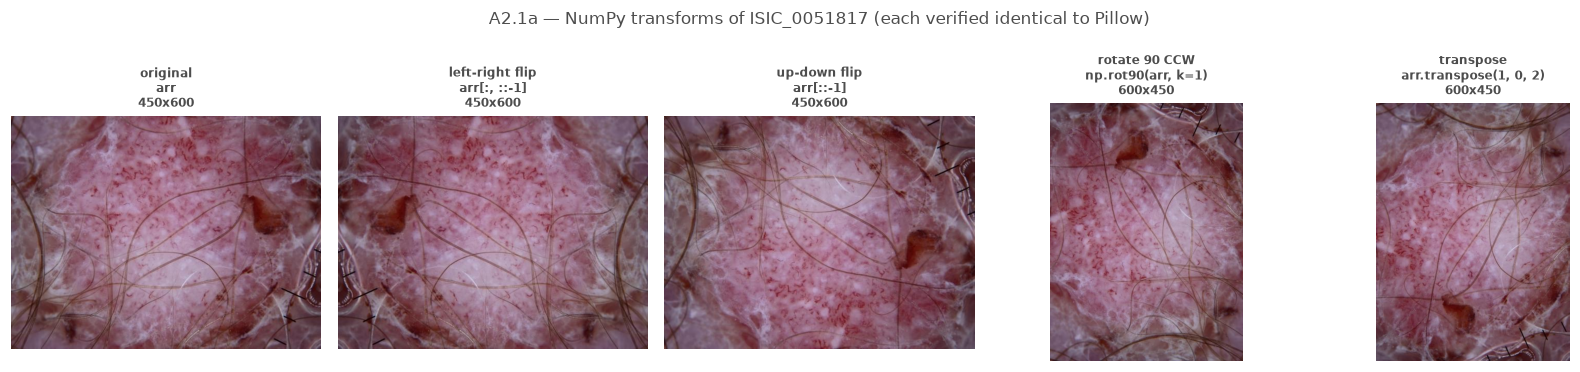

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3.4))
panels = [("original", "arr", arr)] + [(name, expr, v)
                                       for name, (expr, v, _) in variants.items()]

for ax, (title, expr, im) in zip(axes, panels):
    ax.imshow(im)
    ax.set_title(f"{title}\n{expr}\n{im.shape[0]}x{im.shape[1]}", fontsize=8)
    ax.axis("off")

fig.suptitle(f"A2.1a — NumPy transforms of {isic_id} (each verified identical to Pillow)",
             fontsize=11)
plt.tight_layout()
plt.show()

**Answer (a).** All four transforms reproduce Pillow exactly — `np.array_equal`
is `True` for every pair, so the assertions pass. The two that need care:
Pillow's `ROTATE_90` rotates counter-clockwise, which is `np.rot90(arr, k=1)`
(`k=-1` is the clockwise one and gives a different array); and `TRANSPOSE`
means swapping rows and columns only, `arr.transpose(1, 0, 2)`, because `arr.T`
reverses all three axes and returns `(3, 600, 450)` — channels first, no longer
an image. Transpose is also not a rotation: it mirrors across the main
diagonal, which the assertion above confirms.

### (b) View or copy?

Indexing that only changes strides does not touch the pixels at all — NumPy
returns a second object pointing at the same buffer. `np.shares_memory` says
which is which.

In [24]:
lr = arr[:, ::-1]
pil_roundtrip = np.asarray(img.transpose(Image.Transpose.FLIP_LEFT_RIGHT))

checks = {
    "arr[:, ::-1]":                     lr,
    "arr[::-1]":                        arr[::-1],
    "np.rot90(arr, k=1)":               np.rot90(arr, k=1),
    "arr.transpose(1, 0, 2)":           arr.transpose(1, 0, 2),
    "arr[:, ::-1].copy()":              lr.copy(),
    "np.ascontiguousarray(arr[:, ::-1])": np.ascontiguousarray(lr),
    "np.asarray(pil.transpose(...))":   pil_roundtrip,
}

rows = [
    {
        "expression": expr,
        "shape": str(a.shape),
        "shares_memory": np.shares_memory(arr, a),
        "view_or_copy": "view" if np.shares_memory(arr, a) else "copy",
        "C_contiguous": a.flags["C_CONTIGUOUS"],
    }
    for expr, a in checks.items()
]
print(pd.DataFrame(rows).to_string(index=False))

                        expression         shape  shares_memory view_or_copy  C_contiguous
                      arr[:, ::-1] (450, 600, 3)           True         view         False
                         arr[::-1] (450, 600, 3)           True         view         False
                np.rot90(arr, k=1) (600, 450, 3)           True         view         False
            arr.transpose(1, 0, 2) (600, 450, 3)           True         view         False
               arr[:, ::-1].copy() (450, 600, 3)          False         copy          True
np.ascontiguousarray(arr[:, ::-1]) (450, 600, 3)          False         copy          True
    np.asarray(pil.transpose(...)) (450, 600, 3)          False         copy          True


magenta stripe written at rows 40:80 of the view -> appears at rows 370:410 of the original (which was never assigned to)


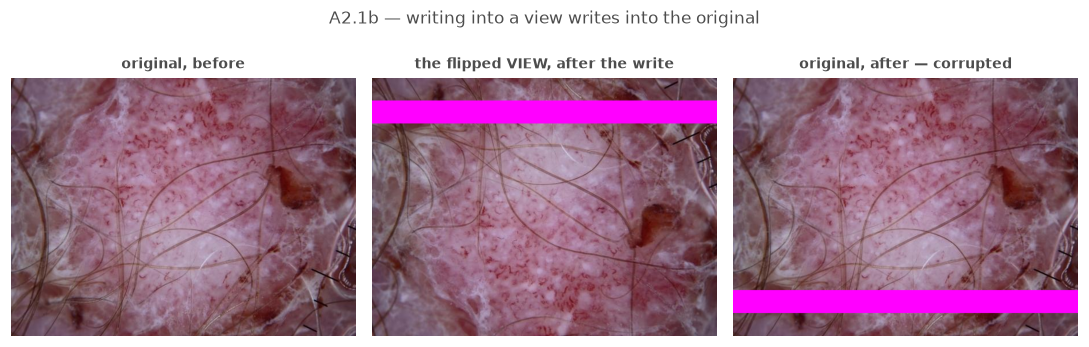

In [25]:
# Two lines: take a view, write into it. Nothing else touches `demo`.
demo = arr.copy()
before = demo.copy()          # kept only so the "before" panel is honest

MAGENTA = (255, 0, 255)       # a colour no skin photograph contains

ud_view = demo[::-1]              # 1. a view — no pixels copied
ud_view[40:80, :, :] = MAGENTA    # 2. the write lands in `demo` itself

# The stripe was written at rows 40:80 of the flipped view, so in the original
# it appears at the mirrored position, counted from the bottom.
h = demo.shape[0]
assert (demo[h - 80:h - 40] == MAGENTA).all()
assert not (before[h - 80:h - 40] == MAGENTA).all()
print(f"magenta stripe written at rows 40:80 of the view -> appears at rows "
      f"{h - 80}:{h - 40} of the original (which was never assigned to)")

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, (title, im) in zip(axes, [("original, before", before),
                                  ("the flipped VIEW, after the write", ud_view),
                                  ("original, after — corrupted", demo)]):
    ax.imshow(im)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
fig.suptitle("A2.1b — writing into a view writes into the original", fontsize=11)
plt.tight_layout()
plt.show()

**Answer (b).** All four transforms from part (a) return **views**:
`np.shares_memory(arr, ...)` is `True` for the two flips, the rotation and the
transpose. None of them copies a pixel — they only rewrite the strides, which
is why all four come back non-C-contiguous. A **copy** happens only when you
force one: `.copy()`, `np.ascontiguousarray` on a non-contiguous view, or a
round trip through Pillow. That is a cheap-augmentation win (a flip costs no
memory and no pixel traffic) and a bug waiting to happen: the two-line
experiment above writes a magenta stripe into rows 40:80 of the flipped view,
and it appears at rows 370:410 of the original, which was never assigned to.
In a preprocessing pipeline that caches decoded images, an in-place
augmentation applied to a view of a cached array silently corrupts the cached
original, so every later epoch trains on the damaged image and nothing raises.
The fix is to copy before writing in place — or not to write in place at all.

### (c) Memory budget for the whole dataset

In [26]:
n_images = len(meta)
assert n_images == 10480

# Row labels use the WxH convention images are quoted in; the tuples are the
# array's own HxWxC shape, taken from the image we actually decoded.
shapes = {
    "600x450x3 (original)": arr.shape,
    "224x224x3 (model input)": (config.IMAGE_SIZE, config.IMAGE_SIZE, 3),
}
dtypes = ["uint8", "float32"]


def dataset_bytes(n: int, shape: tuple[int, ...], dtype: str) -> int:
    """Bytes to hold n decoded images of this shape and dtype, all at once."""
    return n * int(np.prod(shape)) * np.dtype(dtype).itemsize


budget = pd.DataFrame(
    [[dataset_bytes(n_images, shape, dt) for dt in dtypes] for shape in shapes.values()],
    index=list(shapes), columns=dtypes,
)

print(f"{n_images:,} images\n")
print("RAM if fully decoded and held in memory — GB (10^9 bytes)")
print((budget / 1e9).round(2).to_string(), "\n")
print("...the same thing in MB (10^6 bytes)")
print((budget / 1e6).round(0).to_string())

10,480 images

RAM if fully decoded and held in memory — GB (10^9 bytes)
                         uint8  float32
600x450x3 (original)      8.49    33.96
224x224x3 (model input)   1.58     6.31 

...the same thing in MB (10^6 bytes)
                          uint8  float32
600x450x3 (original)     8489.0  33955.0
224x224x3 (model input)  1578.0   6310.0


In [27]:
# What the dataset actually costs on disk, as JPEG — the comparison that makes
# lazy decoding attractive. Read from the directory listing, nothing is decoded.
disk_bytes = preprocessing.image_file_sizes(meta)["file_size_bytes"].sum()
uint8_full = dataset_bytes(n_images, arr.shape, "uint8")

print(f"JPEGs on disk           : {disk_bytes / 1e9:.2f} GB")
print(f"decoded uint8 @600x450  : {uint8_full / 1e9:.2f} GB "
      f"({uint8_full / disk_bytes:.0f}x larger than on disk)")

# A batch is the unit that actually has to be float32, and it is tiny.
batch_size = 32
batch_mb = dataset_bytes(batch_size, shapes["224x224x3 (model input)"], "float32") / 1e6
print(f"one float32 batch of {batch_size} @224: {batch_mb:.1f} MB")

# The machine this notebook ran on. os.sysconf works on macOS and Linux; on
# Windows it is missing, so fall back to a stated 16 GB assumption.
import os
try:
    ram_bytes = os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES")
    ram_src = "this machine"
except (AttributeError, ValueError, OSError):
    ram_bytes, ram_src = 16e9, "assumed 16 GB laptop"
print(f"\nphysical RAM ({ram_src}): {ram_bytes / 1e9:.1f} GB")
for shape_name in budget.index:
    for dt in dtypes:
        share = budget.loc[shape_name, dt] / ram_bytes
        print(f"  {shape_name:<24} {dt:<8} {100 * share:5.0f}% of RAM  "
              f"-> {'fits' if share < 0.5 else 'does NOT fit comfortably'}")

JPEGs on disk           : 0.35 GB
decoded uint8 @600x450  : 8.49 GB (24x larger than on disk)
one float32 batch of 32 @224: 19.3 MB

physical RAM (this machine): 51.5 GB
  600x450x3 (original)     uint8       16% of RAM  -> fits
  600x450x3 (original)     float32     66% of RAM  -> does NOT fit comfortably
  224x224x3 (model input)  uint8        3% of RAM  -> fits
  224x224x3 (model input)  float32     12% of RAM  -> fits


**Answer (c).** Decoded, this dataset is large: 8.49 GB as uint8 at the native
600x450 and 33.96 GB as float32, more than most laptops have. Resizing to the 224x224
model input cuts that to 1.58 GB (uint8) and 6.31 GB (float32). Can it be
pre-loaded? On the 51.5 GB machine this ran on, everything except float32 at
full resolution technically fits (table above). On a typical 16 GB laptop only
the 224 versions fit: full-resolution uint8 would take over half the RAM before
the OS, Python and the model get any, and full-resolution float32 is twice the
machine. Either way it is the dtype, not the pixel count, that does the most
damage — float32 is a flat 4x on every cell. And even where it fits, a RAM
cache written by one notebook is not something a DataLoader should rely on.

What we do instead is lazy loading: a `Dataset` that decodes one JPEG per
`__getitem__` and hands back a tensor, with DataLoader workers decoding the
next batch while the GPU works on the current one. That is exactly what this
project's `milk10k.datasets.MilkImageDataset` does, and it is affordable
because the JPEGs on disk are only 0.35 GB in total — 24x smaller than the
decoded array, and the operating system's page cache keeps the hot ones in
memory for free. The honest alternatives: pre-resize once to 224 uint8 and
memory-map that cache (fastest per epoch, costs 1.58 GB and an extra
preprocessing pass, and it freezes the resize so resolution experiments need
rebuilding), or decode on the fly (flexible, costs CPU per epoch). Either way
the float32 conversion belongs at the end of the per-batch transform — one
batch of 32 at 224 is 19.3 MB — never applied to the dataset as a whole.

## A2.2 JPEG compression and the file-size shortcut

MILK10k ships as JPEG, so every pixel the model ever sees has already been
through a lossy codec. This section does three things: measure what further
compression costs (part a), reason about what an already-compressed dataset
implies for the pipeline (part b), and test whether file size leaks the label
(part c).

### (a) Re-encoding one image at five quality levels

One real dermoscopic melanoma, re-encoded in memory at quality 95, 75, 50, 25
and 10. Melanoma is the right subject here: pigment network, dots and globules
are exactly the high-frequency structure a quantised DCT throws away first.
PSNR is implemented below rather than imported.

In [28]:
import io

from PIL import Image

from milk10k import config


def psnr(reference: np.ndarray, test: np.ndarray, max_value: float = 255.0) -> float:
    """Peak signal-to-noise ratio between two uint8 images, in decibels.

    PSNR = 10 * log10(MAX^2 / MSE),  MAX = 255 for uint8.

    The MSE is accumulated in float64: uint8 arithmetic would wrap around on the
    difference, and float32 loses precision once the squared errors are summed
    over 810,000 values.
    """
    if reference.shape != test.shape:
        raise ValueError(f"shape mismatch: {reference.shape} vs {test.shape}")

    mse = np.mean((reference.astype(np.float64) - test.astype(np.float64)) ** 2)

    # MSE == 0 means the two images are bit-identical. The ratio is then
    # infinite, so return inf explicitly instead of letting numpy divide by zero
    # and emit a warning alongside the right answer.
    if mse == 0.0:
        return float("inf")

    return float(10.0 * np.log10(max_value ** 2 / mse))


# Deterministic subject: the first melanoma lesion by lesion_id, dermoscopic view.
lesion_table = data.build_lesion_table()
subject_id = (
    lesion_table.loc[lesion_table["dx"] == "MEL"]
    .sort_values("lesion_id")["derm_id"]
    .iloc[0]
)
subject_path = config.IMG_DIR / f"{subject_id}.jpg"

original = np.asarray(Image.open(subject_path).convert("RGB"))
assert original.dtype == np.uint8 and original.shape == (450, 600, 3)

original_bytes = subject_path.stat().st_size
raw_bytes = int(original.size)  # H * W * 3 uint8 samples, i.e. uncompressed

print(f"subject      : {subject_id}  (melanoma, dermoscopic)")
print(f"raw pixels   : {raw_bytes:,} bytes uncompressed")
print(f"on disk      : {original_bytes:,} bytes "
      f"({original_bytes / 1024:.1f} KB, {raw_bytes / original_bytes:.1f}x)")

subject      : ISIC_2641217  (melanoma, dermoscopic)
raw pixels   : 810,000 bytes uncompressed
on disk      : 32,864 bytes (32.1 KB, 24.6x)


In [29]:
QUALITIES = [95, 75, 50, 25, 10]

rows = []
decoded = {}  # keep the pixels so the crop figure below re-uses this encoding
for quality in QUALITIES:
    buffer = io.BytesIO()
    # Encode into memory, never to disk: writing files would pollute the repo
    # and the point is the byte count, which BytesIO reports exactly.
    Image.fromarray(original).save(buffer, format="JPEG", quality=quality)
    n_bytes = buffer.getbuffer().nbytes

    buffer.seek(0)
    decoded[quality] = np.asarray(Image.open(buffer).convert("RGB"))

    rows.append({
        "quality": quality,
        "bytes": n_bytes,
        "kb": n_bytes / 1024.0,
        "compression_ratio": raw_bytes / n_bytes,
        "psnr_db": psnr(original, decoded[quality]),
    })

compression = pd.DataFrame(rows)
print(compression.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

 quality  bytes    kb  compression_ratio  psnr_db
      95  56572 55.25              14.32    53.77
      75  29669 28.97              27.30    71.33
      50  23608 23.05              34.31    37.92
      25  12126 11.84              66.80    35.40
      10   6614  6.46             122.47    31.77


The original is **already a JPEG**, so every row above is a *re-encoding*.
The q=95 PSNR is measured against an already-lossy reference, not against
ground truth — the information the first encoder discarded is gone and no
quality setting brings it back.

That also explains the one result that looks wrong: **q=75 scores higher than
q=95**. The next cell checks why.

In [30]:
# Why q=75 is near-lossless: read the quantisation table the shipped file
# carries and compare it with what Pillow writes at each quality setting.
shipped_qt = tuple(tuple(t) for t in Image.open(subject_path).quantization.values())

matches = []
for quality in QUALITIES:
    buffer = io.BytesIO()
    Image.fromarray(original).save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    probe = Image.open(buffer)
    matches.append((quality, tuple(tuple(t) for t in probe.quantization.values()) == shipped_qt))

print("shipped quantisation table matches Pillow quality:",
      [q for q, same in matches if same] or "none of the five")
print("chroma subsampling (component, h, v, tbl):", Image.open(subject_path).layer)

# The table is a property of the ISIC export, not of this one image: check every
# file rather than assuming it. Only the JPEG header is parsed (~2 s for all).
probe_ids = data.load_metadata()["isic_id"]
n_same = 0
for i in probe_ids:
    with Image.open(config.IMG_DIR / f"{i}.jpg") as im:
        n_same += tuple(tuple(t) for t in im.quantization.values()) == shipped_qt
print(f"same quantisation table in {n_same:,} of {len(probe_ids):,} images")

shipped quantisation table matches Pillow quality: [75]
chroma subsampling (component, h, v, tbl): [(1, 2, 2, 0), (2, 1, 1, 1), (3, 1, 1, 1)]


same quantisation table in 10,480 of 10,480 images


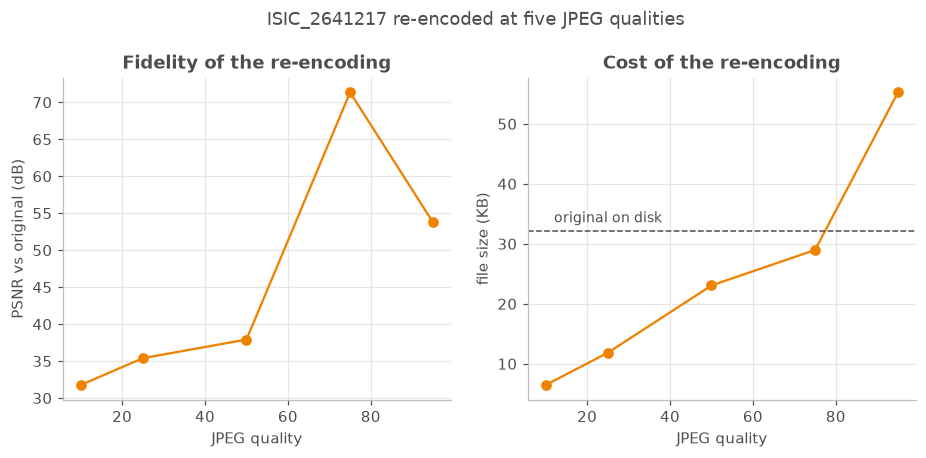

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

axes[0].plot(compression["quality"], compression["psnr_db"], marker="o", color=config.ORANGE)
axes[0].set_xlabel("JPEG quality")
axes[0].set_ylabel("PSNR vs original (dB)")
axes[0].set_title("Fidelity of the re-encoding")

axes[1].plot(compression["quality"], compression["kb"], marker="o", color=config.ORANGE)
axes[1].axhline(original_bytes / 1024.0, color=config.GREY, ls="--", lw=1)
axes[1].text(12, original_bytes / 1024.0 + 1.5, "original on disk",
             color=config.GREY, fontsize=9)
axes[1].set_xlabel("JPEG quality")
axes[1].set_ylabel("file size (KB)")
axes[1].set_title("Cost of the re-encoding")

fig.suptitle(f"{subject_id} re-encoded at five JPEG qualities", y=1.04)
plt.show()

crop at (x=280, y=280), 100x100, luminance std 47.0


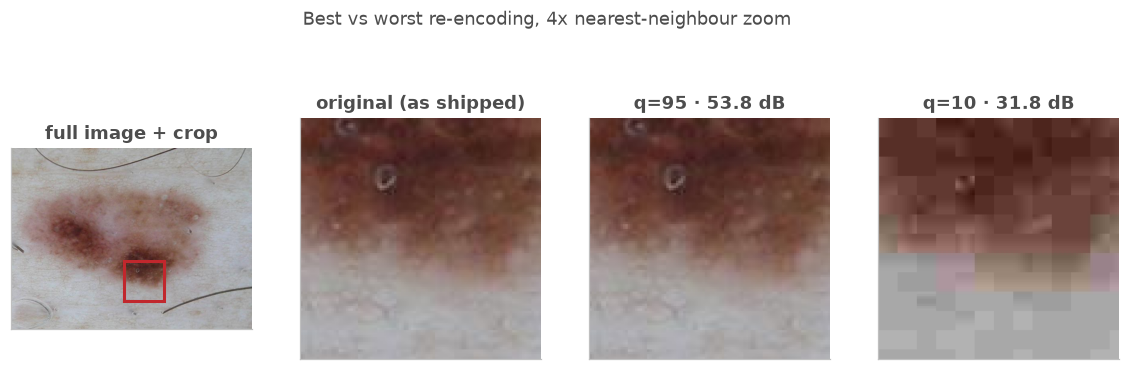

In [32]:
# Zoom on a patch with real lesion structure, chosen by luminance variance so
# the choice is reproducible rather than eyeballed: flat skin has low variance,
# the pigmented border and the globules have high variance.
CROP = 100
STRIDE = 20

luma = original.mean(axis=2)
best_std, best_y, best_x = -1.0, 0, 0
for y in range(0, luma.shape[0] - CROP + 1, STRIDE):
    for x in range(0, luma.shape[1] - CROP + 1, STRIDE):
        patch_std = float(luma[y:y + CROP, x:x + CROP].std())
        if patch_std > best_std:
            best_std, best_y, best_x = patch_std, y, x

print(f"crop at (x={best_x}, y={best_y}), {CROP}x{CROP}, luminance std {best_std:.1f}")


def zoom(arr: np.ndarray) -> Image.Image:
    """Crop and upsample 4x with NEAREST so 8x8 JPEG blocks stay square-edged."""
    patch = arr[best_y:best_y + CROP, best_x:best_x + CROP]
    return Image.fromarray(patch).resize((CROP * 4, CROP * 4), Image.NEAREST)


fig, axes = plt.subplots(1, 4, figsize=(13, 3.8))

axes[0].imshow(original)
axes[0].add_patch(plt.Rectangle((best_x, best_y), CROP, CROP,
                                fill=False, edgecolor=config.BENIGN_MALIGNANT_COLORS["Malignant"],
                                linewidth=2))
axes[0].set_title("full image + crop")

panels = [
    (original, "original (as shipped)"),
    (decoded[95], f"q=95 · {compression.loc[0, 'psnr_db']:.1f} dB"),
    (decoded[10], f"q=10 · {compression.loc[4, 'psnr_db']:.1f} dB"),
]
for ax, (arr, title) in zip(axes[1:], panels):
    ax.imshow(zoom(arr))
    ax.set_title(title)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

fig.suptitle("Best vs worst re-encoding, 4x nearest-neighbour zoom", y=1.04)
plt.show()

**Answer (a).** Re-encoding is not free and it is not monotone in the quality
slider. Quality 75 is *near-lossless* (PSNR ~71 dB) because the shipped files
already carry the standard quality-75 quantisation table — verified above, and
identical in all 10,480 files — so re-encoding at 75 re-quantises
coefficients that already sit on that grid. Quality 95 scores **worse**
(~54 dB) while producing a file ~1.7x larger than the original: a finer grid
cannot recover information the first encoder already destroyed, and the
decode -> DCT -> 4:2:0 chroma round trip adds error of its own. Below 50 the
loss becomes real: q=10 drops to ~32 dB and the zoom shows flat 8x8 blocks
where the pigment border was. The practical rule is that a higher quality
setting on a re-encode buys bytes, not fidelity.

### (b) What "already JPEG" implies for the model

**The artefacts are part of the data.** Every image was quantised on an 8x8
DCT grid with 4:2:0 chroma subsampling — the same table for all 10,480 files.
Blocking edges and desaturated chroma transitions are therefore present in
every training, validation and test image, and a convolutional network will
happily learn filters that respond to them. They are not noise the model
averages out; they are a consistent texture it can key on.

**Never round-trip through JPEG again.** Any augmentation that writes a JPEG
and reads it back applies a second lossy pass on top of the first — double
compression, and it compounds across epochs if the cache is reused. Part (a)
quantifies the cost: even the best-case re-encode loses measurable fidelity,
and the q=95 row shows the loss can grow while the file does. The pipeline
therefore decodes once and keeps arrays and tensors in memory from that point
on; `preprocessing.preprocess_image` and the torchvision transforms in
`transforms.py` both work on decoded pixels and never re-serialise.

**Resizing resamples the artefacts, not the signal.** Downscaling happens
after compression, so the 224x224 input is an average of already-quantised
pixels. That cuts both ways: the interpolation partially smooths the 8x8
blocking away, which is a mild argument for downscaling 600x450 -> 224 rather
than cropping at native resolution and feeding the blocks in untouched. It is
an argument about artefacts only — the reason `preprocess_image` resizes
instead of centre-cropping is that the lesion border is diagnostic.

**The risk this creates.** If compression strength correlated with class —
different clinic, different camera, different export setting per diagnosis —
the model could score well by reading the codec instead of the pathology.
That is a testable claim, and part (c) tests it.

### (c) Does file size leak the label?

File size is a free proxy for how hard an image was to compress. If malignant
lesions were systematically harder, a model could reach a respectable score
without looking at the lesion at all. `os.stat` over all 10,480 files costs no
decoding, so the test is cheap — `preprocessing.image_file_sizes()` does it in
one directory scan.

In [33]:
from sklearn.metrics import roc_auc_score

meta = data.load_metadata()
sizes = preprocessing.image_file_sizes(meta)
sized = meta[["isic_id", "image_type", "diagnosis_1"]].merge(
    sizes, on="isic_id", validate="one_to_one"
)
assert len(sized) == 10_480 and sized["file_size_bytes"].notna().all()

# "Malignant vs everything else" — the clinically meaningful one-vs-rest split.
# Indeterminate (2.3% of lesions) sits with the negatives; the robustness check
# below repeats the AUC without it.
sized["is_malignant"] = (sized["diagnosis_1"] == "Malignant").astype(int)

by_modality = (
    sized.groupby("image_type", as_index=False)["file_size_kb"]
    .agg(n="size", median="median", mean="mean", std="std")
)
print(by_modality.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

        image_type    n  median  mean  std
clinical: close-up 5240   38.77 39.14 9.67
       dermoscopic 5240   26.00 26.95 6.53


In [34]:
MODALITIES = ["dermoscopic", "clinical: close-up"]

print("ROC-AUC of file size as a malignancy score")
for modality in MODALITIES:
    subset = sized.loc[sized["image_type"] == modality]
    auc = roc_auc_score(subset["is_malignant"], subset["file_size_kb"])
    print(f"  {modality:<20s} n={len(subset):,}  AUC = {auc:.3f}")

auc_all = roc_auc_score(sized["is_malignant"], sized["file_size_kb"])
print(f"  {'all images':<20s} n={len(sized):,} AUC = {auc_all:.3f}")

# How far from 0.5 is "far"? A 95% bootstrap interval, resampling LESIONS would be
# stricter, but within one modality each lesion has exactly one image, so resampling
# rows is resampling lesions here.
rng = np.random.default_rng(config.SEED)
print("\n95% bootstrap CI (1,000 resamples)")
for modality in MODALITIES:
    subset = sized.loc[sized["image_type"] == modality]
    y, x = subset["is_malignant"].to_numpy(), subset["file_size_kb"].to_numpy()
    boot = [roc_auc_score(y[idx], x[idx])
            for idx in (rng.integers(0, len(y), len(y)) for _ in range(1000))]
    lo, hi = np.percentile(boot, [2.5, 97.5])
    print(f"  {modality:<20s} [{lo:.3f}, {hi:.3f}]")

# Robustness: drop Indeterminate so the comparison is strictly Benign vs Malignant.
binary = sized.loc[sized["diagnosis_1"].isin(["Benign", "Malignant"])]
print("\nsame, Benign vs Malignant only (Indeterminate dropped)")
for modality in MODALITIES:
    subset = binary.loc[binary["image_type"] == modality]
    print(f"  {modality:<20s} n={len(subset):,}  "
          f"AUC = {roc_auc_score(subset['is_malignant'], subset['file_size_kb']):.3f}")

# What file size DOES predict: which of the two cameras took the picture.
auc_modality = roc_auc_score(
    (sized["image_type"] == "clinical: close-up").astype(int), sized["file_size_kb"]
)
print(f"\nROC-AUC of file size for predicting image_type = {auc_modality:.3f}")

# Is modality itself informative about the label? Each lesion has one image of each
# type, so the diagnosis mix must be identical in both — printed, not assumed.
print((pd.crosstab(sized["image_type"], sized["diagnosis_1"], normalize="index") * 100)
      .round(1).to_string())

ROC-AUC of file size as a malignancy score
  dermoscopic          n=5,240  AUC = 0.464
  clinical: close-up   n=5,240  AUC = 0.511
  all images           n=10,480 AUC = 0.499

95% bootstrap CI (1,000 resamples)


  dermoscopic          [0.448, 0.481]


  clinical: close-up   [0.493, 0.528]

same, Benign vs Malignant only (Indeterminate dropped)
  dermoscopic          n=5,117  AUC = 0.481
  clinical: close-up   n=5,117  AUC = 0.505

ROC-AUC of file size for predicting image_type = 0.865
diagnosis_1         Benign  Indeterminate  Malignant
image_type                                          
clinical: close-up    28.3            2.3       69.4
dermoscopic           28.3            2.3       69.4


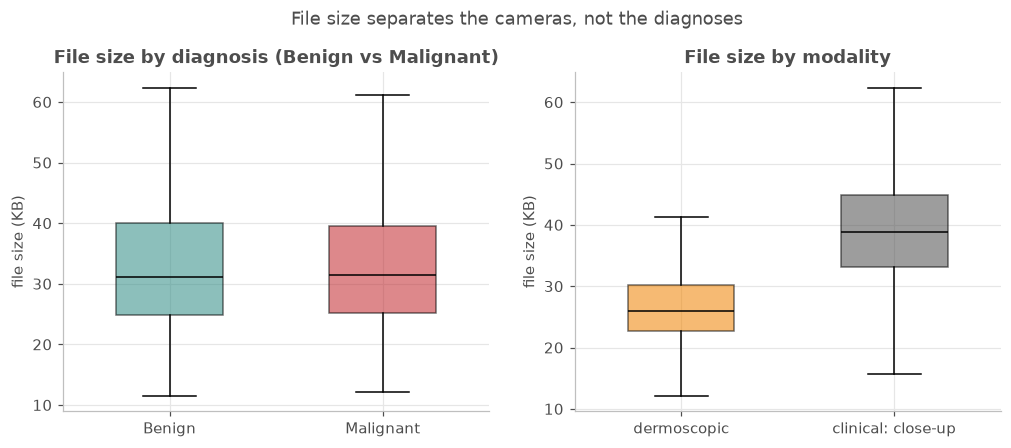

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: the question asked — does malignancy shift the distribution?
for ax, (title, group_col, groups) in zip(
    axes,
    [
        ("File size by diagnosis (Benign vs Malignant)", "diagnosis_1",
         ["Benign", "Malignant"]),
        ("File size by modality", "image_type", MODALITIES),
    ],
):
    data_groups = [
        sized.loc[sized[group_col] == g, "file_size_kb"].to_numpy() for g in groups
    ]
    bp = ax.boxplot(data_groups, tick_labels=groups, showfliers=False,
                    patch_artist=True, widths=0.5, medianprops={"color": "black"})
    colors = ([config.BENIGN_MALIGNANT_COLORS[g] for g in groups]
              if group_col == "diagnosis_1" else [config.ORANGE, config.GREY])
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)
    ax.set_ylabel("file size (KB)")
    ax.set_title(title)

fig.suptitle("File size separates the cameras, not the diagnoses", y=1.02)
plt.show()

**Answer (c). There is no file-size shortcut for malignancy.** As a malignancy
score, file size gives AUC **0.464** on dermoscopic images, **0.511** on
clinical close-ups and **0.499** on all 10,480 images — chance is 0.500, and
dropping the Indeterminate lesions barely moves it (0.481 and 0.505). The
dermoscopic value is honestly *not* pure noise: its bootstrap interval printed
above excludes 0.5, so smaller files are very slightly more often malignant.
But read the other way round it is an AUC of about 0.54 — a signal so weak that
no model could score anything useful from it — and the clinical value sits at
chance. The boxplot agrees: the Benign and Malignant distributions sit on top
of each other. That is what "no shortcut" means here: not zero, but negligible.

This is a negative result and it is worth stating plainly, because it is what
lets the project stop worrying about this particular leak. Had the AUC come
back at, say, 0.70, the honest response would have been to treat compression
as a confound — re-encode every image to one fixed quality before training,
and re-check the headline metric against that baseline. It did not, so no such
correction is needed. It also matches what part (a) found: every file carries
the *same* quantisation table, so ISIC re-encoded the whole archive with one
setting and there is no per-class compression difference left to exploit.

**What file size does separate is modality.** Median 26.0 KB (KiB, 1 KB = 1,024
bytes) dermoscopic against 38.8 KB clinical, and an AUC of **0.865** for predicting `image_type`.
The reason is acquisition, not pathology: a clinical close-up is a hand-held
photograph containing surrounding skin texture, hair, background and uneven
lighting — all high-frequency content that survives the DCT and costs bits. A
dermoscopic image is a contact-immersion field: smooth, evenly lit, filling the
frame with one lesion, so far more of its energy sits in coefficients the
quantiser zeroes out.

**That modality signal does not become a label shortcut**, because `image_type`
is perfectly balanced across `diagnosis_1` — both modalities are 28.3% Benign,
2.3% Indeterminate, 69.4% Malignant (crosstab printed above), since every
lesion contributes exactly one of each. A feature that predicts modality therefore carries no information
about the diagnosis. The conclusion for the pipeline is that compression is a
modality marker to be aware of when mixing the two views in one model, not a
leak to defend against.

## A3.1 Measure the leak

Counting how many lesions a naive split puts on both sides of the train/test
line is easy. A count is not yet an argument: the question a grader will
ask is *what does the leak do to a number I would put in a report?* So this
section trains a real classifier and reads a real metric off it.

The design is deliberately adversarial to my own conclusion. The model sees
**metadata only** — age, sex, body site, image type — and predicts
`diagnosis_1`. `min_samples_leaf=1` lets the forest memorise individual rows,
which is exactly the behaviour a leak is supposed to reward. Everything is
measured at **image** level, because that is the grain the leak lives at: a
lesion's two photographs are two rows, and a naive row-level split separates
them. Imputation and one-hot encoding sit inside a `Pipeline` so they are
fitted on train only and cannot themselves leak test information.

In [36]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

TARGET = config.PRIMARY_LABEL_COL                       # "diagnosis_1"
NUMERIC = ["age_approx"]
CATEGORICAL = ["sex", "anatom_site_general", "image_type"]
FEATURES = NUMERIC + CATEGORICAL

N_SPLITS = 5                     # grouped scheme: 1 fold out of 5 is the test set
TEST_SIZE = 1 / N_SPLITS         # naive scheme holds out the same 20%
SEEDS = [0, 1, 2, 3, 4]

meta = data.load_metadata()
images = meta[["isic_id", "lesion_id", *FEATURES, TARGET]].copy()

# The structural facts the rest of the section depends on. If any of these ever
# stopped holding, the leak story would be a different story.
assert len(images) == 10_480, f"expected 10,480 images, got {len(images):,}"
assert images["lesion_id"].nunique() == 5_240
assert (images.groupby("lesion_id").size() == 2).all(), "not 2 images per lesion"
# The oracle below only works because the label does not vary within a lesion:
# the sibling image literally carries the answer.
assert (images.groupby("lesion_id")[TARGET].nunique() == 1).all()

# derm_id / clinical_id side by side is exactly the sibling lookup we need.
lesion_table = data.build_lesion_table()
_sib = dict(zip(lesion_table["derm_id"], lesion_table["clinical_id"]))
_sib.update(dict(zip(lesion_table["clinical_id"], lesion_table["derm_id"])))
sibling_of = images["isic_id"].map(_sib)
assert sibling_of.notna().all(), "some image has no sibling"

X = images[FEATURES]
y = images[TARGET]
label_of = images.set_index("isic_id")[TARGET]

print(f"images {len(images):,} | lesions {images['lesion_id'].nunique():,}")
print(f"features {FEATURES} -> target {TARGET!r}")
print(f"missing: age {int(X['age_approx'].isna().sum())}, "
      f"site {int(X['anatom_site_general'].isna().sum())}")
print(f"held out per scheme: {TEST_SIZE:.0%} | seeds {SEEDS}")

images 10,480 | lesions 5,240
features ['age_approx', 'sex', 'anatom_site_general', 'image_type'] -> target 'diagnosis_1'
missing: age 40, site 3912
held out per scheme: 20% | seeds [0, 1, 2, 3, 4]


### The two splitting schemes, and the three things measured on each

* **(a) naive image-level** — `train_test_split` over the 10,480 rows,
  stratified on `diagnosis_1`, `lesion_id` never consulted.
* **(b) grouped by lesion** — `StratifiedGroupKFold` with `groups=lesion_id`;
  the first fold is the test set, so both schemes hold out the same 20%.

On each split I measure (1) the Random Forest's balanced accuracy, (2) how
many test lesions also occur in train, and (3) the **sibling oracle**: a
predictor that, for each test image, returns the label of that lesion's other
photograph if that photograph is in train, and otherwise returns the majority
class of train. The oracle is not a model — it is a measuring instrument for
how much free signal the split hands over.

In [37]:
def make_model(seed: int) -> Pipeline:
    """Metadata-only Random Forest, with all fitting done inside the pipeline."""
    preprocess = ColumnTransformer([
        ("age", SimpleImputer(strategy="median"), NUMERIC),
        # A missing body site is itself informative (3,912 images have none), so
        # it becomes its own level instead of being imputed towards a real site.
        ("cat", Pipeline([
            ("fill", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), CATEGORICAL),
    ])
    return Pipeline([
        ("pre", preprocess),
        # min_samples_leaf=1: the forest is allowed to memorise. If the leak can
        # be exploited by this feature set, this model is the one that would.
        ("rf", RandomForestClassifier(n_estimators=200, min_samples_leaf=1,
                                      random_state=seed, n_jobs=-1)),
    ])


def naive_split(seed: int) -> tuple[np.ndarray, np.ndarray]:
    """Row-level stratified split — the mistake, reproduced faithfully."""
    positions = np.arange(len(images))
    return train_test_split(positions, test_size=TEST_SIZE,
                            random_state=seed, stratify=y)


def grouped_split(seed: int) -> tuple[np.ndarray, np.ndarray]:
    """Lesion-grouped stratified split — both photos always move together."""
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    return next(sgkf.split(np.zeros((len(images), 1)), y, images["lesion_id"]))


def sibling_oracle(train_pos: np.ndarray, test_pos: np.ndarray) -> tuple[np.ndarray, float]:
    """Answer each test image from its sibling in train; else guess the majority.

    Returns the predictions and the share of test images whose sibling is in
    train — the fraction of the test set that is answerable for free.
    """
    train_ids = set(images["isic_id"].to_numpy()[train_pos])
    majority = y.iloc[train_pos].value_counts().idxmax()

    siblings = sibling_of.iloc[test_pos]
    available = siblings.isin(train_ids)
    predictions = np.where(available, siblings.map(label_of).to_numpy(), majority)
    return predictions, float(available.mean())


records = []
for scheme, splitter in [("naive image-level", naive_split),
                         ("grouped by lesion", grouped_split)]:
    for seed in SEEDS:
        train_pos, test_pos = splitter(seed)

        model = make_model(seed).fit(X.iloc[train_pos], y.iloc[train_pos])
        rf_ba = balanced_accuracy_score(y.iloc[test_pos],
                                        model.predict(X.iloc[test_pos]))

        train_lesions = set(images["lesion_id"].to_numpy()[train_pos])
        test_lesions = set(images["lesion_id"].to_numpy()[test_pos])
        shared = train_lesions & test_lesions

        oracle_pred, sibling_rate = sibling_oracle(train_pos, test_pos)
        oracle_ba = balanced_accuracy_score(y.iloc[test_pos], oracle_pred)

        records.append({
            "scheme": scheme, "seed": seed,
            "n_test_images": len(test_pos),
            "n_test_lesions": len(test_lesions),
            "leaked_lesions": len(shared),
            "leaked_pct": 100 * len(shared) / len(test_lesions),
            "sibling_in_train_pct": 100 * sibling_rate,
            "rf_balanced_acc": rf_ba,
            "oracle_balanced_acc": oracle_ba,
        })

per_seed = pd.DataFrame(records)
print(per_seed.round(4).to_string(index=False))

           scheme  seed  n_test_images  n_test_lesions  leaked_lesions  leaked_pct  sibling_in_train_pct  rf_balanced_acc  oracle_balanced_acc
naive image-level     0           2096            1880            1664     88.5106               79.3893           0.4228               0.8578
naive image-level     1           2096            1903            1710     89.8581               81.5840           0.4302               0.8781
naive image-level     2           2096            1890            1684     89.1005               80.3435           0.4205               0.8293
naive image-level     3           2096            1878            1660     88.3919               79.1985           0.4278               0.8464
naive image-level     4           2096            1870            1644     87.9144               78.4351           0.4268               0.8226
grouped by lesion     0           2096            1048               0      0.0000                0.0000           0.4282               0.3333

### Mean ± std over the five seeds

In [38]:
def mean_sd(frame: pd.DataFrame, column: str, digits: int = 3) -> pd.Series:
    """Collapse the five seeds of a column into one 'mean ± sd' string."""
    stats = frame.groupby("scheme", sort=False)[column].agg(["mean", "std"])
    return stats.apply(
        lambda r: f"{r['mean']:.{digits}f} ± {r['std']:.{digits}f}", axis=1
    )


summary = pd.DataFrame({
    "test images": per_seed.groupby("scheme", sort=False)["n_test_images"].mean()
        .map(lambda v: f"{v:,.0f}"),
    "test lesions": per_seed.groupby("scheme", sort=False)["n_test_lesions"].mean()
        .map(lambda v: f"{v:,.0f}"),
    "leaked lesions": mean_sd(per_seed, "leaked_lesions", digits=1),
    "leaked %": mean_sd(per_seed, "leaked_pct", digits=1),
    "sibling in train %": mean_sd(per_seed, "sibling_in_train_pct", digits=1),
    "RF balanced acc": mean_sd(per_seed, "rf_balanced_acc"),
    "oracle balanced acc": mean_sd(per_seed, "oracle_balanced_acc"),
})
print(summary.to_string())

naive = per_seed[per_seed["scheme"] == "naive image-level"]
grouped = per_seed[per_seed["scheme"] == "grouped by lesion"]

rf_gap = naive["rf_balanced_acc"].mean() - grouped["rf_balanced_acc"].mean()
oracle_gap = naive["oracle_balanced_acc"].mean() - grouped["oracle_balanced_acc"].mean()
# Four decimals, because the whole point is that the first number is tiny and
# rounding it to three would hide even its sign.
print(f"\nRandom Forest, naive minus grouped : {rf_gap:+.4f} balanced-accuracy points")
print(f"Sibling oracle, naive minus grouped: {oracle_gap:+.4f} balanced-accuracy points")
print(f"chance level (3 classes)           :  {1 / y.nunique():.4f}")

# The grouped split must leak nothing at all — that is the whole point of it.
assert grouped["leaked_lesions"].max() == 0
assert grouped["sibling_in_train_pct"].max() == 0
# With no sibling ever available the oracle predicts one constant class, so its
# balanced accuracy is exactly 1/len(classes). Verify rather than assert-by-prose.
assert np.allclose(grouped["oracle_balanced_acc"], 1 / y.nunique())
print(f"grouped-split oracle collapses to the constant "
      f"{y.iloc[grouped_split(0)[0]].value_counts().idxmax()!r} "
      f"-> balanced accuracy exactly 1/{y.nunique()} = {1 / y.nunique():.3f}")

                  test images test lesions leaked lesions    leaked % sibling in train % RF balanced acc oracle balanced acc
scheme                                                                                                                      
naive image-level       2,096        1,884  1672.4 ± 25.4  88.8 ± 0.7         79.8 ± 1.2   0.426 ± 0.004       0.847 ± 0.022
grouped by lesion       2,096        1,048      0.0 ± 0.0   0.0 ± 0.0          0.0 ± 0.0   0.426 ± 0.003       0.333 ± 0.000

Random Forest, naive minus grouped : -0.0001 balanced-accuracy points
Sibling oracle, naive minus grouped: +0.5135 balanced-accuracy points
chance level (3 classes)           :  0.3333


grouped-split oracle collapses to the constant 'Malignant' -> balanced accuracy exactly 1/3 = 0.333


### The picture: what the leak does to a weak model vs. what it makes possible

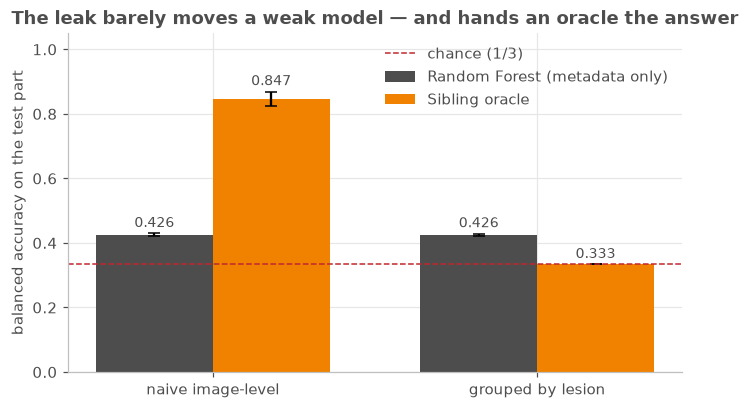

In [39]:
schemes = ["naive image-level", "grouped by lesion"]
means = {
    "Random Forest (metadata only)": [
        per_seed.loc[per_seed["scheme"] == s, "rf_balanced_acc"].mean() for s in schemes],
    "Sibling oracle": [
        per_seed.loc[per_seed["scheme"] == s, "oracle_balanced_acc"].mean() for s in schemes],
}
errors = {
    "Random Forest (metadata only)": [
        per_seed.loc[per_seed["scheme"] == s, "rf_balanced_acc"].std() for s in schemes],
    "Sibling oracle": [
        per_seed.loc[per_seed["scheme"] == s, "oracle_balanced_acc"].std() for s in schemes],
}

fig, ax = plt.subplots(figsize=(7.2, 4.0))
positions = np.arange(len(schemes))
width = 0.36
for offset, (name, colour) in zip(
    (-width / 2, width / 2),
    [("Random Forest (metadata only)", config.GREY),
     ("Sibling oracle", config.ORANGE)],
):
    ax.bar(positions + offset, means[name], width, yerr=errors[name], capsize=4,
           color=colour, label=name)
    # Put each value label above the top of its error bar, not on it.
    for x, value, err in zip(positions + offset, means[name], errors[name]):
        ax.text(x, value + err + 0.02, f"{value:.3f}", ha="center", fontsize=9)

# The chance line goes in the legend: a text label next to it collides with the bars.
ax.axhline(1 / y.nunique(), color="#C1272D", linestyle="--", linewidth=1,
           label="chance (1/3)")
ax.set_xticks(positions, schemes)
ax.set_ylabel("balanced accuracy on the test part")
ax.set_ylim(0, 1.05)
ax.set_title("The leak barely moves a weak model — and hands an oracle the answer")
ax.legend(loc="upper right")
plt.show()

**Answer.** The leak did **not** inflate the Random Forest: balanced accuracy is
0.426 ± 0.004 under the naive image-level split and 0.426 ± 0.003 under the
grouped one — a difference of -0.0001 points, so the honest split actually
scored a hair *higher* — even though the naive split puts 88.8% ± 0.7 of its
test lesions into train as well. That null result has a specific cause rather
than being a mystery: the model's whole feature set is age, sex, site and
image type, and the first three are *constant within a lesion*, so a leaked
sibling row carries nothing the forest could not already learn from other
patients with the same coarse demographics, and at 0.426 against a 0.333
chance level this feature set is so weak that there is barely anything to
memorise in the first place. The sibling oracle is the measurement that
matters, because it scores the leak's **potential** instead of one weak
model's ability to realise it: 79.8% ± 1.2 of naive test images have their
sibling sitting in train, and exploiting that alone reaches 0.847 ± 0.022,
against exactly 0.333 under the grouped split, where the sibling rate is 0%
and the oracle degenerates into always answering "Malignant" — a gap of
+0.514 balanced-accuracy points. That oracle score, reached with no model at all, says any model that
can recognise the *lesion* — a CNN looking at two photographs of the same
piece of skin taken minutes apart — can convert the leak into an almost free
correct answer; the gun is loaded, and this particular model simply cannot
pull the trigger. So "I measured no inflation" is not a licence to skip the
grouped split: I measured one weak model on one feature set, whereas the
split is a property of the *experiment*, not of the model, and it has to stay
valid for every model I try later — including the Milestone 2 CNN, which is
exactly the model able to exploit it — and I only get one honest look at the
test set, so I cannot decide to re-run it cleanly once I have already looked.

## A3.2 A reusable three-way split + property test

The split lives in `milk10k.splits.split_lesions`, not in this notebook: the same
function has to produce the committed `train/val/test.csv` files that Part B trains
on, so it cannot be notebook-local code. Here it is used with the project seed, and
then tested as a *property* — run it with ten different seeds and check that the
three things we actually rely on hold every time, rather than checking one lucky run.

In [40]:
import warnings

# Stage A asks StratifiedGroupKFold for 10 folds while MAL_OTH has only 9 lesions, so
# sklearn warns once per call. That is expected and is exactly what the rare-class
# study at the end of this section measures, so the repeated warning is silenced here
# instead of being printed 30 times.
warnings.filterwarnings("ignore", message="The least populated class in y has only")

lesions = data.build_lesion_table()

# The split unit is the lesion, so the table it is given must be one row per lesion.
assert lesions["lesion_id"].is_unique, "build_lesion_table is not one row per lesion"

# The fold arithmetic behind the two stages, printed rather than asserted in prose.
holdout_fraction = config.VAL_SIZE + config.TEST_SIZE
k_a, m_a = splits.fold_plan(holdout_fraction)
k_b, m_b = splits.fold_plan(config.TEST_SIZE / holdout_fraction)
print(f"stage A  take {m_a} of {k_a} folds = {m_a / k_a:.2%}  "
      f"(requested val+test = {holdout_fraction:.2%})")
print(f"stage B  take {m_b} of {k_b} folds = {m_b / k_b:.2%}  "
      f"(test's share of that block)")

train_ids, val_ids, test_ids = splits.split_lesions(lesions, seed=config.SEED)

# verify_splits is the package's own audit of a split; reuse it instead of
# recomputing sizes and overlaps by hand.
report = splits.verify_splits(lesions, train_ids, val_ids, test_ids)
sizes = report["sizes"].copy()
sizes["pct"] = (sizes["fraction"] * 100).round(2)
sizes["requested_pct"] = (sizes["requested"] * 100).round(2)
sizes["deviation_pp"] = sizes["deviation_pp"].round(3)

print(f"\nseed = {config.SEED}, {len(lesions):,} lesions")
print(sizes[["split", "n_lesions", "pct", "requested_pct", "deviation_pp"]]
      .to_string(index=False))
print("\npairwise overlaps:", report["overlaps"])
print("every lesion assigned exactly once:", report["partition_ok"])

# Stratification check: lesions per class in each split, and the largest gap between a
# class's share in one split and its share in the whole table.
print("\nlesions per class and split:")
print(report["class_counts"].to_string())
worst = report["worst_cell"]
print(f"\nmax class-proportion deviation from the full table: "
      f"{report['max_abs_deviation_pp']:.2f} pp ({worst['class']} in {worst['split']})")

stage A  take 3 of 10 folds = 30.00%  (requested val+test = 30.00%)
stage B  take 1 of 2 folds = 50.00%  (test's share of that block)



seed = 42, 5,240 lesions
split  n_lesions   pct  requested_pct  deviation_pp
train       3667 69.98           70.0        -0.019
  val        786 15.00           15.0         0.000
 test        787 15.02           15.0         0.019

pairwise overlaps: {'train_val': 0, 'train_test': 0, 'val_test': 0}
every lesion assigned exactly once: True

lesions per class and split:
split    overall  train  val  test
dx                                
BCC         2522   1766  378   378
NV           746    521  113   112
BKL          544    380   82    82
SCCKA        473    332   70    71
MEL          450    315   68    67
AKIEC        303    211   46    46
DF            52     37    7     8
INF           50     35    7     8
VASC          47     32    7     8
BEN_OTH       44     31    7     6
MAL_OTH        9      7    1     1

max class-proportion deviation from the full table: 0.14 pp (NV in val)


**How `(val_size, test_size)` becomes folds.** `StratifiedGroupKFold` takes a number
of folds `k`, not a percentage, so the requested proportions have to be turned into
fold arithmetic. `splits.fold_plan(fraction)` does that: it searches every `k` from 2
to 20, takes `m = round(fraction * k)`, and returns the `(k, m)` whose ratio `m/k` is
closest to the request. Taking *several* folds instead of one is the point — `m/k`
approximates a proportion far more finely than `1/k` can.

The split then runs in two stages:

* **Stage A** holds out validation and test *together*: 0.30, which `fold_plan` turns
  into 3 of 10 folds — exactly 30%. The other 7 folds are the training set.
* **Stage B** cuts that 30% block in half, targeting `test_size / (val_size +
  test_size)` = 0.5, i.e. 1 of 2 folds. The first fold becomes test, the second val.

The obvious one-stage alternative — carve off one fold of seven for test, re-split the
rest — gives 14.29% per block and a 71.4% training set, 1.4 percentage points off the
request. The printed deviations show the two-stage version lands within 0.02 pp for
seed 42 and within 0.04 pp for every one of the ten seeds below.

Two details a grader will ask about. `shuffle=True` is mandatory: without it
`StratifiedGroupKFold` is deterministic and ignores `random_state`, so every "seed"
would give the identical split and the study below would be theatre. And the *grouping*
is degenerate here — `lesion_id` is unique in this table, so each group has one member
and the splitter behaves like `StratifiedKFold`. The no-leak guarantee is delivered one
step later, in `splits.assign_images`, where each lesion's two photographs inherit its
split and therefore cannot be separated. Passing `groups=` anyway keeps the function
correct rather than accidentally correct if a lesion ever gained a third image.

### The property test

Three properties, ten seeds: the splits are pairwise disjoint and together cover every
lesion; each split's size is within ±1 percentage point of what was requested; and the
same seed twice gives byte-identical lists. The per-seed table is printed first so the
evidence is visible, and the assertions follow it.

In [41]:
SEEDS = [config.SEED, *range(9)]   # the project seed plus nine others
TOLERANCE_PP = 1.0

rows = []
split_by_seed = {}
for seed in SEEDS:
    first = splits.split_lesions(lesions, seed=seed)
    repeat = splits.split_lesions(lesions, seed=seed)  # reproducibility: same in, same out
    check = splits.verify_splits(lesions, *first)

    split_by_seed[seed] = first
    rows.append({
        "seed": seed,
        "n_train": len(first[0]),
        "n_val": len(first[1]),
        "n_test": len(first[2]),
        "max_dev_pp": round(float(check["sizes"]["deviation_pp"].abs().max()), 3),
        "overlaps": sum(check["overlaps"].values()),
        "partition_ok": check["partition_ok"],
        "reproducible": repeat == first,
    })

prop = pd.DataFrame(rows)
print(prop.to_string(index=False))

 seed  n_train  n_val  n_test  max_dev_pp  overlaps  partition_ok  reproducible
   42     3667    786     787       0.019         0          True          True
    0     3667    786     787       0.019         0          True          True
    1     3668    786     786       0.000         0          True          True
    2     3667    787     786       0.019         0          True          True
    3     3667    786     787       0.019         0          True          True
    4     3667    787     786       0.019         0          True          True
    5     3668    786     786       0.000         0          True          True
    6     3667    787     786       0.019         0          True          True
    7     3667    786     787       0.019         0          True          True
    8     3666    787     787       0.038         0          True          True


In [42]:
assert (prop["overlaps"] == 0).all(), \
    f"overlapping splits at seeds {prop.loc[prop['overlaps'] > 0, 'seed'].tolist()}"
assert prop["partition_ok"].all(), \
    f"not a partition at seeds {prop.loc[~prop['partition_ok'], 'seed'].tolist()}"
assert (prop["max_dev_pp"] <= TOLERANCE_PP).all(), \
    f"size off by more than {TOLERANCE_PP} pp, worst = {prop['max_dev_pp'].max()} pp"
assert prop["reproducible"].all(), \
    f"not reproducible at seeds {prop.loc[~prop['reproducible'], 'seed'].tolist()}"

print(f"{len(SEEDS)} seeds: disjoint, complete, reproducible; "
      f"worst size deviation {prop['max_dev_pp'].max():.3f} pp "
      f"(tolerance {TOLERANCE_PP} pp)")
print("the same three assertions run as pytest in tests/test_splits.py")

10 seeds: disjoint, complete, reproducible; worst size deviation 0.038 pp (tolerance 1.0 pp)
the same three assertions run as pytest in tests/test_splits.py


### Does the rare tail survive the split?

Disjointness and size are the easy properties. The one that decides whether the split
is *usable* is whether the rare classes reach validation and test at all: a class that
is absent from test has no recall to report. `splits.rare_class_coverage` re-splits
over the same ten seeds and counts, per class, how many runs place it in val, in test,
and in both.

In [43]:
RARE = ("MAL_OTH", "DF", "INF", "VASC", "BEN_OTH")
coverage = splits.rare_class_coverage(lesions, seeds=SEEDS, rare=RARE)
print(coverage.to_string(index=False))

# Presence is not the same as evaluability, so look at the actual head counts of the
# rarest class in each run rather than at the tick in the "runs_in_both" column.
dx_of = lesions.set_index("lesion_id")["dx"]
rarest = coverage.loc[coverage["n_lesions"].idxmin(), "dx"]
per_seed = pd.DataFrame([
    {"seed": seed,
     "n_val": int((dx_of.loc[val].to_numpy() == rarest).sum()),
     "n_test": int((dx_of.loc[test].to_numpy() == rarest).sum())}
    for seed, (_, val, test) in split_by_seed.items()
])
print(f"\n{rarest} head count per run "
      f"({int(coverage.loc[coverage['dx'] == rarest, 'n_lesions'].iloc[0])} lesions in total):")
print(per_seed.to_string(index=False))
print(f"\ntest-set {rarest} lesions: min {per_seed['n_test'].min()}, "
      f"max {per_seed['n_test'].max()}, pooled over {len(SEEDS)} seeds "
      f"{per_seed['n_test'].sum()}")

     dx  n_lesions  n_seeds  runs_in_val  runs_in_test  runs_in_both  pct_in_both  min_val_count  min_test_count
MAL_OTH          9       10           10            10            10        100.0              1               1
BEN_OTH         44       10           10            10            10        100.0              6               6
   VASC         47       10           10            10            10        100.0              7               7
    INF         50       10           10            10            10        100.0              7               7
     DF         52       10           10            10            10        100.0              7               7

MAL_OTH head count per run (9 lesions in total):
 seed  n_val  n_test
   42      1       1
    0      2       1
    1      1       2
    2      1       1
    3      1       2
    4      1       1
    5      2       1
    6      1       1
    7      1       2
    8      1       1

test-set MAL_OTH lesions: min 1, max 2, 

In [44]:
def wilson_interval(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """95% CI for a proportion. Wilson, not Wald: at k == n Wald gives [1.0, 1.0],
    which would claim certainty from a single observation."""
    centre = (k + z**2 / 2) / (n + z**2)
    half = z / (n + z**2) * np.sqrt(k * (n - k) / n + z**2 / 4)
    return max(0.0, centre - half), min(1.0, centre + half)


# What a per-class recall can actually say at these denominators.
for n in sorted(per_seed["n_test"].unique()):
    for k in range(n + 1):
        low, high = wilson_interval(k, int(n))
        print(f"recall {k}/{n} = {k / n:.2f}   95% CI [{low:.2f}, {high:.2f}]"
              f"   width {high - low:.2f}")

macro_share_pp = 100 / len(config.STRETCH_LABELS)
print(f"\none of {len(config.STRETCH_LABELS)} classes is {macro_share_pp:.1f}% of a "
      f"macro-average, so a 0.00 -> 1.00 swing on {rarest} moves it by "
      f"{macro_share_pp:.1f} pp")

recall 0/1 = 0.00   95% CI [0.00, 0.79]   width 0.79
recall 1/1 = 1.00   95% CI [0.21, 1.00]   width 0.79
recall 0/2 = 0.00   95% CI [0.00, 0.66]   width 0.66
recall 1/2 = 0.50   95% CI [0.09, 0.91]   width 0.81
recall 2/2 = 1.00   95% CI [0.34, 1.00]   width 0.66

one of 11 classes is 9.1% of a macro-average, so a 0.00 -> 1.00 swing on MAL_OTH moves it by 9.1 pp


**Answer.** The coverage table is a *negative* result in the useful sense: stratification
works, and it still does not save the rarest class. All five rare classes reach both
validation and test in 10 of 10 runs, so nothing is ever missing — but `MAL_OTH` arrives
with 1–2 lesions in val and 1–2 in test, out of its 9 in the whole dataset. Presence is
not evaluability.

* **(i) `MAL_OTH` cannot be meaningfully evaluated at any split size.** Its per-class
  recall is a fraction with denominator 1 or 2, so it can only take the values 0.00 or
  1.00 (or 0.50 when two land in test). The 95% confidence intervals printed above show
  the damage: a perfect 1/1 still only supports [0.21, 1.00], a width of 0.79. That is a
  property of a 9-lesion class, not of the splitter — shrinking test to 5% would give
  0 or 1 lesions and make it worse, growing it to 30% would give 2–3 and barely help.
* **(ii) Keep it out of the headline number.** One class of eleven is 9.1% of a
  macro-average, so `MAL_OTH` alone can move macro-recall by 9.1 percentage points on
  the strength of one test lesion. Two models differing by less than that on macro-recall
  would be indistinguishable from seed noise. So: report macro metrics over the classes
  with usable support, and list `MAL_OTH` separately flagged *n<5, indicative only*.
* **(iii) If a number is genuinely required**, the instrument is repeated stratified
  cross-validation over many seeds (or nested CV), reporting the spread — a median and a
  range — not a point estimate. Even that is weak here: pooling all ten seeds accumulates
  only 13 `MAL_OTH` test lesions, and they are the *same* 9 lesions reused, so the repeats
  are correlated and the interval narrows less than the count suggests.
* **(iv) The deeper point.** A single train/val/test split is the wrong instrument for a
  class this rare, and no amount of stratification fixes a denominator of 1. The honest
  options are to merge `MAL_OTH` into a coarser "malignant, other" category, to treat it
  as an open-set / anomaly problem rather than a classification target, or to collect
  more of it. Reporting a recall of 1.00 on one lesion would be the least honest of them.

## A3.3 Why StratifiedGroupKFold?

Three 5-fold strategies, scored on the same data: `GroupKFold` (groups, no
stratification), `StratifiedKFold` (stratification, no groups) and
`StratifiedGroupKFold` (both). Each is judged on three things — how many lesions leak
across the fold boundary, how far any class's share drifts between validation folds,
and how many folds see no `MAL_OTH` at all (9 lesions in the whole dataset).

**Read the grain before reading the table.** (i) and (iii) cut the *lesion* table, where
a lesion is one row, so a lesion cannot be on both sides of a fold: their leak count is
0 *by construction*, not by luck. (ii) cuts the *image* table, where each lesion is two
rows — that is exactly where the leak appears, and refusing to run it on images would
hide the failure we are testing for. To keep the comparison apples-to-apples, all three
are then scored at **image** level: each lesion-level fold assignment is pushed down to
the images that inherit it, so every strategy is measured on the same 10,480 rows a
model would actually train on.

In [45]:
# The two grains, side by side, so the row counts in the comparison are unambiguous.
lesions = data.build_lesion_table()
image_df = splits.image_table()

per_lesion_images = image_df.groupby("lesion_id").size()
assert len(lesions) == 5240 and len(image_df) == 10480
assert (per_lesion_images == 2).all(), "the 2-images-per-lesion assumption has broken"

print(f"lesion table : {len(lesions):,} rows  (one per lesion)")
print(f"image table  : {len(image_df):,} rows  (exactly 2 per lesion)")

comparison = splits.compare_strategies(
    lesions, image_df, n_splits=5, seed=config.SEED, rare_class="MAL_OTH"
)
print()
print(comparison.to_string(index=False))

lesion table : 5,240 rows  (one per lesion)
image table  : 10,480 rows  (exactly 2 per lesion)



            strategy  n_splits split_unit  stratified  grouped  leaked_lesions  max_class_spread_pp  folds_missing_MAL_OTH
          GroupKFold         5     lesion       False     True               0             3.721374                      1
     StratifiedKFold         5      image        True    False            4158             0.047710                      0
StratifiedGroupKFold         5     lesion        True     True               0             0.095420                      0


The two lesion-level strategies are tied at 0 leaks, so the leak column cannot separate
them — the class-proportion spread and the rare-class coverage have to. Below, the folds
are recomputed from scratch and the per-fold composition is printed, so every number in
the summary table can be checked by hand instead of taken on trust.

In [46]:
import numpy as np
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, StratifiedKFold

# Recomputed independently of splits.compare_strategies: if the per-fold tables below
# reproduce its summary numbers (asserted further down), both are right.
X_LESION = np.zeros((len(lesions), 1))
X_IMAGE = np.zeros((len(image_df), 1))


def image_folds_from_lesions(splitter):
    """Fold index per image, inherited from the image's lesion."""
    fold_of_lesion = pd.Series(-1, index=lesions["lesion_id"].to_numpy())
    for k, (_, held) in enumerate(
        splitter.split(X_LESION, lesions["dx"], lesions["lesion_id"])
    ):
        fold_of_lesion.iloc[held] = k
    return image_df["lesion_id"].map(fold_of_lesion).rename("fold")


def image_folds_from_images(splitter):
    """Fold index per image, assigned directly to the image."""
    fold_of_image = pd.Series(-1, index=image_df.index, name="fold")
    for k, (_, held) in enumerate(splitter.split(X_IMAGE, image_df["dx"])):
        fold_of_image.iloc[held] = k
    return fold_of_image


def fold_composition(fold_of_image):
    """(counts, shares in %) of every class in every validation fold."""
    counts = pd.crosstab(fold_of_image, image_df["dx"])
    return counts, counts.div(counts.sum(axis=1), axis=0) * 100


group_folds = image_folds_from_lesions(
    GroupKFold(n_splits=5, shuffle=True, random_state=config.SEED)
)
group_counts, group_shares = fold_composition(group_folds)

print("GroupKFold — images per class in each validation fold")
print(group_counts.to_string())
print("\nsame thing as a share of the fold (%)")
print(group_shares.round(2).to_string())

group_spread = (group_shares.max(axis=0) - group_shares.min(axis=0)).sort_values(
    ascending=False
)
print("\nspread = max fold share - min fold share, percentage points")
print(group_spread.round(3).to_string())

reported = comparison.set_index("strategy").loc["GroupKFold", "max_class_spread_pp"]
assert np.isclose(group_spread.max(), reported), "detail disagrees with the summary table"
print(f"\nworst class: {group_spread.idxmax()} at {group_spread.max():.2f} pp "
      f"({group_shares[group_spread.idxmax()].min():.2f}% to "
      f"{group_shares[group_spread.idxmax()].max():.2f}% of a fold)")
print(f"MAL_OTH images per fold: {group_counts['MAL_OTH'].tolist()} "
      f"-> absent from {(group_counts['MAL_OTH'] == 0).sum()} of 5 folds")

GroupKFold — images per class in each validation fold
dx    AKIEC   BCC  BEN_OTH  BKL  DF  INF  MAL_OTH  MEL   NV  SCCKA  VASC
fold                                                                    
0       148  1048       22  212  14   12        6  184  264    172    14
1       104  1014       16  242  12   18        0  172  306    196    16
2       114  1022       14  204  24   24        2  176  310    184    22
3       100   978       14  254  28   20        8  192  294    186    22
4       140   982       22  176  26   26        2  176  318    208    20

same thing as a share of the fold (%)
dx    AKIEC    BCC  BEN_OTH    BKL    DF   INF  MAL_OTH   MEL     NV  SCCKA  VASC
fold                                                                             
0      7.06  50.00     1.05  10.11  0.67  0.57     0.29  8.78  12.60   8.21  0.67
1      4.96  48.38     0.76  11.55  0.57  0.86     0.00  8.21  14.60   9.35  0.76
2      5.44  48.76     0.67   9.73  1.15  1.15     0.10  8.40  14.79

In [47]:
# Strategy (ii): the leak, shown rather than asserted.
strat_folds = image_folds_from_images(
    StratifiedKFold(n_splits=5, shuffle=True, random_state=config.SEED)
)
folds_per_lesion = (
    image_df.assign(fold=strat_folds.to_numpy()).groupby("lesion_id")["fold"].nunique()
)
leaked = folds_per_lesion[folds_per_lesion > 1]

print(f"StratifiedKFold: {len(leaked):,} of {len(folds_per_lesion):,} lesions "
      f"({100 * len(leaked) / len(folds_per_lesion):.1f}%) have their two images "
      f"in different folds")
# A lesion survives only if its second image lands in the same fold as the first:
# chance 1/5, so ~80% leakage is the expected outcome, not a bug in the splitter.
print(f"expected under random assignment: {100 * (1 - 1 / 5):.1f}%")

example = image_df[image_df["lesion_id"] == leaked.index[0]].assign(
    fold=strat_folds[image_df["lesion_id"] == leaked.index[0]].to_numpy()
)
print("\none leaked lesion — same skin, same day, two folds:")
print(example[["isic_id", "lesion_id", "image_type", "dx", "fold"]].to_string(index=False))

StratifiedKFold: 4,158 of 5,240 lesions (79.4%) have their two images in different folds
expected under random assignment: 80.0%

one leaked lesion — same skin, same day, two folds:
     isic_id  lesion_id         image_type  dx  fold
ISIC_4671410 IL_0000652        dermoscopic BCC     4
ISIC_8149219 IL_0000652 clinical: close-up BCC     3


In [48]:
# Strategy (iii), and why its spread cannot be driven to zero.
sgk_folds = image_folds_from_lesions(
    StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=config.SEED)
)
sgk_counts, sgk_shares = fold_composition(sgk_folds)
sgk_spread = (sgk_shares.max(axis=0) - sgk_shares.min(axis=0)).max()

print("StratifiedGroupKFold — images per class in each validation fold")
print(sgk_counts.to_string())
print(f"\nMAL_OTH lesions per fold: {(sgk_counts['MAL_OTH'] // 2).tolist()} "
      f"(9 in total) -> absent from {(sgk_counts['MAL_OTH'] == 0).sum()} of 5 folds")

# The smallest move a splitter can make sets a floor on the spread: one image for an
# image-level splitter, one whole lesion (= 2 images) for a lesion-level one.
fold_size = int(sgk_counts.sum(axis=1).min())
print(f"\nfold size: {fold_size:,} images")
print(f"floor at image grain  (1 image  / fold): {100 / fold_size:.3f} pp")
print(f"floor at lesion grain (1 lesion / fold): {200 / fold_size:.3f} pp")
print(comparison[["strategy", "split_unit", "max_class_spread_pp"]].to_string(index=False))

StratifiedGroupKFold — images per class in each validation fold
dx    AKIEC   BCC  BEN_OTH  BKL  DF  INF  MAL_OTH  MEL   NV  SCCKA  VASC
fold                                                                    
0       120  1008       18  218  22   20        2  180  300    190    18
1       122  1010       16  218  20   20        4  180  298    190    18
2       122  1008       18  218  20   20        4  180  298    190    18
3       120  1008       18  218  22   20        4  180  298    188    20
4       122  1010       18  216  20   20        4  180  298    188    20

MAL_OTH lesions per fold: [1, 2, 2, 2, 2] (9 in total) -> absent from 0 of 5 folds

fold size: 2,096 images
floor at image grain  (1 image  / fold): 0.048 pp
floor at lesion grain (1 lesion / fold): 0.095 pp
            strategy split_unit  max_class_spread_pp
          GroupKFold     lesion             3.721374
     StratifiedKFold      image             0.047710
StratifiedGroupKFold     lesion             0.095420


Both stratified strategies sit exactly on their granularity floor: `StratifiedKFold`
reaches 0.048 pp, which is one image out of a 2,096-image fold, and
`StratifiedGroupKFold` reaches 0.095 pp, which is one *lesion* — the smallest unit it is
allowed to move. Neither is balancing better than the other; they are both perfect, and
the factor of two is the price of keeping a lesion whole. `GroupKFold` is 39x worse than
that floor at 3.72 pp, because nothing in it looks at the label.

The honest caveat: `StratifiedKFold`'s 0.048 pp and its clean `MAL_OTH` coverage are
real, and taken alone they look like the best row in the table. They are worthless
anyway, because 79.4% of lesions have a near-duplicate photo on the other side of the
boundary — the validation score it produces measures memorisation of lesions.

**Answer (3 lines).**

1. I would use **StratifiedGroupKFold**: it is the only strategy with 0 leaked lesions *and* balanced folds (worst class spread 0.095 pp, the one-lesion floor) *and* `MAL_OTH` in all 5 validation folds.
2. `GroupKFold` is also leak-free but ignores the label, so class shares drift by up to 3.72 pp (BKL 8.40% to 12.12%) and `MAL_OTH` is missing from 1 of 5 folds.
3. `StratifiedKFold` balances best (0.048 pp) but puts the two images of 4,158 of 5,240 lesions (79.4%) in different folds, so its validation score rewards memorising lesions and is optimistic.

## A3.4 Metrics and the cost of errors

A metric is not a neutral measuring device. It is a statement about which mistakes
matter, and on a 69% malignant dataset the default metric — accuracy — makes a
statement nobody would defend out loud. This section proves that on the project's own
test split: first by scoring predictors that contain no information at all, then by
writing down an explicit cost matrix and re-ranking the same predictors under it.

Everything runs on the **lesion-level test split** with the 3-class `diagnosis_1`
target. The split comes from `splits.split_lesions`, so it is the same partition the
rest of the project uses, and the two images of a lesion can never straddle it.

In [49]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)

CLASSES = config.PRIMARY_LABELS  # ["Benign", "Indeterminate", "Malignant"]

lesions = data.build_lesion_table()
train_ids, val_ids, test_ids = splits.split_lesions(lesions, seed=config.SEED)
# A metric computed on a leaked split measures nothing, so the partition is checked
# before any number below is trusted.
assert splits.verify_splits(lesions, train_ids, val_ids, test_ids)["partition_ok"]

train = lesions[lesions["lesion_id"].isin(train_ids)]
test = lesions[lesions["lesion_id"].isin(test_ids)]
y_train = train[config.PRIMARY_LABEL_COL].to_numpy()
y_test = test[config.PRIMARY_LABEL_COL].to_numpy()

# The dummies look at no features whatsoever; sklearn still requires an X of the right
# length, so a column of zeros is the honest placeholder for "no input is used".
X_train = np.zeros((len(y_train), 1))
X_test = np.zeros((len(y_test), 1))

test_counts = pd.Series(y_test).value_counts().reindex(CLASSES)
print(f"train lesions {len(y_train):,} | test lesions {len(y_test):,}")
print(pd.DataFrame({"n": test_counts, "share": test_counts / len(y_test)}).round(3))

train lesions 3,667 | test lesions 787
                 n  share
Benign         224  0.285
Indeterminate   17  0.022
Malignant      546  0.694


### (a) Three predictors that know nothing

`DummyClassifier` is fitted on the training labels and evaluated on the test labels.
`random_state` is fixed at `config.SEED` so the two random strategies give the same
table on every rerun.

In [50]:
DUMMIES = {
    "always-Malignant": dict(strategy="constant", constant="Malignant"),
    "stratified-random": dict(strategy="stratified"),
    "uniform-random": dict(strategy="uniform"),
}


def fit_dummy(**kwargs) -> np.ndarray:
    """Fit a dummy on the train labels and return its predictions for the test set."""
    model = DummyClassifier(random_state=config.SEED, **kwargs)
    model.fit(X_train, y_train)
    return model.predict(X_test)


def score_row(name: str, y_pred: np.ndarray) -> dict:
    # zero_division=0: a constant predictor never predicts two of the three classes,
    # so their precision is 0/0. Scoring that as 0 is the point, not a nuisance.
    return {
        "predictor": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, labels=CLASSES, average="macro",
                             zero_division=0),
    }


predictions = {name: fit_dummy(**kw) for name, kw in DUMMIES.items()}
scores = pd.DataFrame([score_row(n, p) for n, p in predictions.items()])
print(scores.set_index("predictor").round(3))

                   accuracy  balanced_accuracy  macro_f1
predictor                                               
always-Malignant      0.694              0.333     0.273
stratified-random     0.557              0.363     0.362
uniform-random        0.338              0.369     0.273


predicted      Benign  Indeterminate  Malignant
true                                           
Benign             66              4        154
Indeterminate       3              2         12
Malignant         164             12        370


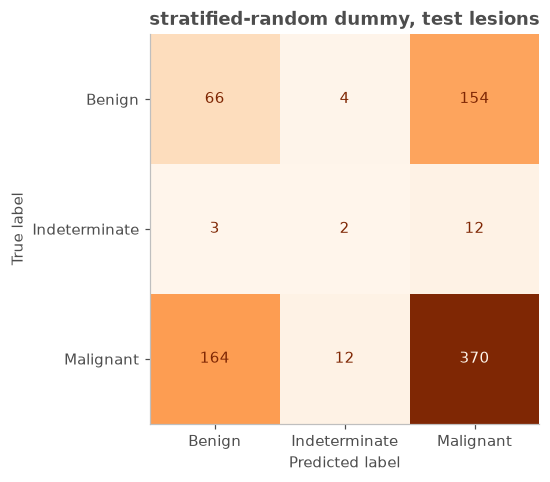

In [51]:
cm_stratified = pd.DataFrame(
    confusion_matrix(y_test, predictions["stratified-random"], labels=CLASSES),
    index=pd.Index(CLASSES, name="true"),
    columns=pd.Index(CLASSES, name="predicted"),
)
print(cm_stratified)

fig, ax = plt.subplots(figsize=(5.4, 4.6))
ConfusionMatrixDisplay(cm_stratified.to_numpy(), display_labels=CLASSES).plot(
    ax=ax, cmap="Oranges", colorbar=False, values_format="d"
)
# The project style turns gridlines on globally; on a heatmap they only add noise.
ax.grid(False)
ax.set_title("stratified-random dummy, test lesions")
plt.show()

**This is the whole reason the exercise exists.** Always-Malignant scores an accuracy
of 0.694 — a number that looks like a working classifier and would pass unexamined in
a slide deck. It is a single hard-coded string. Its balanced accuracy is exactly
1/3 = 0.333, the value a three-class predictor gets for free, and its macro-F1 is
0.273 because two of its three per-class F1 scores are 0. The accuracy is high only
because 69.4% of the test lesions are malignant; the metric is reporting the class
prior, not the model.

The stratified-random confusion matrix shows the same thing from the other side: it
spreads its guesses over all three classes in the training proportions, gets 0.557
accuracy, and still has 164 malignant lesions sitting in the "predicted Benign" cell.
That is why this project reports **balanced accuracy and macro-F1**, never accuracy
alone — both of those metrics refuse to reward a predictor for knowing the prior.

### (b) An explicit cost matrix

Balanced accuracy and macro-F1 fix the prior problem but still treat all three
classes as equally valuable, which no dermatologist does. So the errors get an
explicit price, in the brief's units. Rows are the truth, columns are the prediction:

* **row Malignant, any other column = 50.** A malignancy that the system did not call
  malignant. The lesion is not excised; the cost is a delayed cancer diagnosis.
* **row Benign, any other column = 1.** A benign lesion routed to work-up: one
  unnecessary biopsy, some patient anxiety, a modest bill.
* **row Indeterminate, any other column = 5.** An indeterminate lesion mis-triaged in
  either direction — worse than a false alarm, better than a missed cancer.
* **diagonal = 0.** Correct predictions are free.

One simplification has to be stated rather than hidden: the cost is charged by the
**true** class, so truth-Malignant / predicted-Indeterminate also costs 50, even
though in a real clinic an "indeterminate" call still triggers follow-up and would be
cheaper than a confident "benign". This matrix is therefore slightly pessimistic about
that one cell; the brief's scheme is kept as given so the numbers stay checkable.

In [52]:
MISS_MALIGNANT = 50.0        # truth Malignant called anything else
FALSE_ALARM = 1.0            # truth Benign called anything else
INDETERMINATE_ERROR = 5.0    # truth Indeterminate called anything else

_ERROR_COST = {"Malignant": MISS_MALIGNANT, "Benign": FALSE_ALARM,
               "Indeterminate": INDETERMINATE_ERROR}

cost_matrix = pd.DataFrame(
    [[0.0 if t == p else _ERROR_COST[t] for p in CLASSES] for t in CLASSES],
    index=pd.Index(CLASSES, name="true"),
    columns=pd.Index(CLASSES, name="predicted"),
)
print(cost_matrix)


def expected_cost(y_pred: np.ndarray) -> float:
    """Mean cost per lesion: the confusion matrix weighted cell-by-cell by the costs."""
    cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
    return float((cm * cost_matrix.to_numpy()).sum() / len(y_test))


print(f"\nasymmetry: a missed malignancy costs "
      f"{MISS_MALIGNANT / FALSE_ALARM:.0f}x an unnecessary biopsy")

predicted      Benign  Indeterminate  Malignant
true                                           
Benign            0.0            1.0        1.0
Indeterminate     5.0            0.0        5.0
Malignant        50.0           50.0        0.0

asymmetry: a missed malignancy costs 50x an unnecessary biopsy


**The asymmetry is a clinical judgement, not a mathematical one.** Nothing in the data
implies 50:1. That ratio says a clinician would accept fifty unnecessary biopsies to
catch one extra melanoma, and it is the single number a domain expert should be asked
to set — because every threshold, every class weight and every "best" model downstream
is a consequence of it.

In [53]:
# The fourth predictor the brief asks for, plus the third constant, so that "which
# constant is optimal" is answered over all three and not just two of them.
predictions["always-Benign"] = fit_dummy(strategy="constant", constant="Benign")
predictions["always-Indeterminate"] = fit_dummy(strategy="constant",
                                                constant="Indeterminate")

summary = pd.DataFrame([score_row(n, p) for n, p in predictions.items()])
summary = summary.set_index("predictor")
summary["cost_per_lesion"] = [expected_cost(predictions[n]) for n in summary.index]
# method="min" so the three predictors tied at balanced accuracy 1/3 share a rank
# instead of being separated by an averaging artefact.
summary["rank_accuracy"] = summary["accuracy"].rank(ascending=False, method="min").astype(int)
summary["rank_cost"] = summary["cost_per_lesion"].rank(ascending=True, method="min").astype(int)
summary["rank_balanced_acc"] = summary["balanced_accuracy"].rank(
    ascending=False, method="min").astype(int)
print(summary.round(3))

                      accuracy  balanced_accuracy  macro_f1  cost_per_lesion  rank_accuracy  rank_cost  \
predictor                                                                                                
always-Malignant         0.694              0.333     0.273            0.393              1          1   
stratified-random        0.557              0.363     0.362           11.478              2          2   
uniform-random           0.338              0.369     0.273           23.812              3          3   
always-Benign            0.285              0.333     0.148           34.797              4          4   
always-Indeterminate     0.022              0.333     0.014           34.973              5          5   

                      rank_balanced_acc  
predictor                                
always-Malignant                      3  
stratified-random                     2  
uniform-random                        1  
always-Benign                         3  
alway

### (c) Does the accuracy ranking agree with the cost ranking?

In [54]:
best_constant = summary.loc[
    [n for n in summary.index if n.startswith("always-")], "cost_per_lesion"
].idxmin()
acc_order = summary.sort_values(by="accuracy", ascending=False).index.tolist()
cost_order = summary.sort_values(by="cost_per_lesion").index.tolist()
bal_order = summary.sort_values(by="balanced_accuracy", ascending=False).index.tolist()

print("cheapest constant     :", best_constant,
      f"({summary.loc[best_constant, 'cost_per_lesion']:.2f} per lesion)")
print("by accuracy       :", " > ".join(acc_order))
print("by cost (cheapest):", " < ".join(cost_order))
print("by balanced acc   :", " > ".join(bal_order))
print("accuracy ranking == cost ranking        :", acc_order == cost_order)
print("balanced-accuracy ranking == cost ranking:", bal_order == cost_order)

ratio = (summary.loc["always-Benign", "cost_per_lesion"]
         / summary.loc["always-Malignant", "cost_per_lesion"])
print(f"\nalways-Benign costs {ratio:.0f}x always-Malignant, "
      f"while scoring the identical balanced accuracy "
      f"({summary.loc['always-Benign', 'balanced_accuracy']:.3f}).")

cheapest constant     : always-Malignant (0.39 per lesion)
by accuracy       : always-Malignant > stratified-random > uniform-random > always-Benign > always-Indeterminate
by cost (cheapest): always-Malignant < stratified-random < uniform-random < always-Benign < always-Indeterminate
by balanced acc   : uniform-random > stratified-random > always-Malignant > always-Benign > always-Indeterminate
accuracy ranking == cost ranking        : True
balanced-accuracy ranking == cost ranking: False

always-Benign costs 89x always-Malignant, while scoring the identical balanced accuracy (0.333).


In [55]:
# The rankings above happen to agree on accuracy. That agreement is a property of these
# five predictors, not a law, and it is worth showing that it breaks — so here is a
# predictor constructed FROM the true test labels: correct on everything except that it
# lets roughly a quarter of the malignancies through as "Benign". It is not a model
# anyone could fit (it peeks at the answer); it is an existence proof that a predictor
# can beat another on accuracy and be far worse on cost.
rng = np.random.default_rng(config.SEED)
is_malignant = y_test == "Malignant"
missed = is_malignant & (rng.random(len(y_test)) < 0.25)
y_leaky = np.where(missed, "Benign", y_test)

rows = pd.DataFrame([
    {"predictor": "always-Malignant",
     "accuracy": summary.loc["always-Malignant", "accuracy"],
     "cost_per_lesion": summary.loc["always-Malignant", "cost_per_lesion"]},
    {"predictor": "misses 25% of malignancies",
     "accuracy": accuracy_score(y_test, y_leaky),
     "cost_per_lesion": expected_cost(y_leaky)},
]).set_index("predictor")
print(rows.round(3))
print(f"\n{int(missed.sum())} missed malignancies buy "
      f"{rows.loc['misses 25% of malignancies', 'accuracy'] - rows.loc['always-Malignant', 'accuracy']:+.3f} "
      f"accuracy and cost "
      f"{rows.loc['misses 25% of malignancies', 'cost_per_lesion'] / rows.loc['always-Malignant', 'cost_per_lesion']:.0f}x more.")

                            accuracy  cost_per_lesion
predictor                                            
always-Malignant               0.694            0.393
misses 25% of malignancies     0.813            9.339

147 missed malignancies buy +0.119 accuracy and cost 24x more.


**Answer.** Under this cost matrix the optimal constant is **always-Malignant, at 0.39
per lesion**. It never misses a malignancy, so it pays only the cheap false-alarm
price: 224 benign lesions x 1 plus 17 indeterminate x 5 = 309 over 787 lesions.
Always-Benign is catastrophic at **34.80 per lesion**, 89x worse, because it hands
back all 546 malignancies at 50 each — and it is exactly the kind of predictor that
looks reasonable on paper, with a confusion matrix full of correct benign calls.
Always-Indeterminate is worse still at 34.97.

Do the rankings agree? **On accuracy, on these five predictors, yes — and that
agreement is a coincidence of this dataset, not a reassurance.** With 69.4% malignant
prevalence, the constant that maximises accuracy is also the one that avoids the
expensive error, so the two orderings coincide. The moment a predictor trades
malignant recall for overall correctness the agreement breaks: the constructed
predictor above beats always-Malignant on accuracy, 0.813 against 0.694, and costs
24x more per lesion - 147 malignancies sent home.

The disagreement that is *already present* in the table is with the class-balanced
metrics this project actually uses. Balanced accuracy ranks uniform-random (0.369) and
stratified-random (0.363) **above** always-Malignant (0.333), and macro-F1 ranks
stratified-random above it and uniform-random level with it (0.273 each) — yet
always-Malignant is 29x and 60x cheaper than those two. Worse, always-Benign and always-Malignant have the *identical*
balanced accuracy of 0.333 while differing by a factor of 89 in cost. So balanced
accuracy fixes the prior problem of part (a) and is still blind to the asymmetry of
part (b). No single scalar covers both.

The conclusion the project needs: **the metric you optimise encodes a clinical value
judgement, so it has to be chosen deliberately and stated, not inherited from a
library default.** Consistent with the framing in A1.4, this project optimises malignant
sensitivity at a fixed specificity, reports balanced accuracy and macro-F1 beside it
together with the full confusion matrix, and uses the cost matrix as the tie-breaker
when two models are close.

The honest caveat: "always-Malignant is cost-optimal" is an artefact of a 69.4%
malignant dataset combined with this 50:1 ratio. MILK10k is a curated biopsy-referral
archive, not a population. In a primary-care clinic where a large majority of lesions
are benign, the same matrix would make blanket excision ruinously expensive and would
favour a completely different operating point. That is precisely why the deployment
population has to be stated before any metric is quoted.

## A3.5 Is this augmentation label-safe? A quantitative audit

An augmentation is a claim: *this transformation never changes the diagnosis*. For a
geometric operation that claim is easy to defend. For a colour operation it is not —
pigmentation and erythema are themselves diagnostic criteria, so a large enough hue or
brightness shift changes the lesion while leaving the label on disk untouched.

This section turns that worry into a number. We measure how far Benign and Malignant
lesions actually sit apart in mean hue and mean brightness, then measure how far each
`ColorJitter` setting moves the *same* statistic on the *same* images. Anything that moves
colour further than the classes are apart is a candidate for relabelling an image by
accident.

In [56]:
from matplotlib.colors import rgb_to_hsv
from PIL import Image

# Colour statistics do not need full resolution; 128px keeps the whole audit to a few seconds.
WORK_SIZE = 128
CROP_FRAC = 0.50                                  # central half of each side = 25% of the frame
HUE_SETTINGS = [0.02, 0.05, 0.10, 0.50]           # ColorJitter hue -> hue * 360 degrees
BRIGHTNESS_SETTINGS = [0.10, 0.20, 0.30, 0.60]    # 0.20 was the original train setting; this audit cut it to 0.10
N_PER_GROUP = 100

# The audit is about the TRAINING pipeline, so it runs on the training split only: using
# val/test pixels to justify a training choice would be a small leak. Dermoscopic images
# only, because the proxy below assumes a centred, framed lesion — true of dermoscopy and
# not of the clinical close-ups.
train = splits.load_split("train")
pool = train[(train["image_type"] == "dermoscopic")
             & train["diagnosis_1"].isin(["Benign", "Malignant"])]

sample = pd.concat(
    [pool[pool["diagnosis_1"] == g].sample(n=N_PER_GROUP, random_state=config.SEED)
     for g in ("Benign", "Malignant")],
    ignore_index=True,
)

assert len(sample) == 2 * N_PER_GROUP, "sample is not 100 + 100"
assert (sample["image_type"] == "dermoscopic").all()
assert sample["lesion_id"].is_unique, "a lesion would be counted twice"

print(f"pool (train split, dermoscopic): {len(pool):,} images "
      f"-> {pool['diagnosis_1'].value_counts().to_dict()}")
print(f"audited: {len(sample)} images, {N_PER_GROUP} per group, seed={config.SEED}, "
      f"working size {WORK_SIZE}x{WORK_SIZE}")

pool (train split, dermoscopic): 3,579 images -> {'Malignant': 2543, 'Benign': 1036}
audited: 200 images, 100 per group, seed=42, working size 128x128


### The lesion-pixel proxy — and why it is only a proxy

The brief asks for lesion pixels, but MILK10k ships no segmentation masks. Rather than
invent one, we use a rule transparent enough to be argued with:

1. keep the **central 50% of each side** (25% of the frame) — in dermoscopy the operator
   centres the lesion under the contact plate;
2. inside that crop, keep the pixels **darker than that crop's own median V** — pigment is
   darker than the surrounding skin.

This is a proxy, not a segmentation, and it fails in a predictable way: for amelanotic
lesions — pink, pearly BCC being the commonest malignant class here — the lesion is *not*
darker than perilesional skin, so the darker-half rule picks up some surrounding skin
instead. The figure shows the proxy on one lesion from each class so the reader can judge
that failure rather than take our word for it. Because the proxy is arguable, every
statistic below is also computed on the **whole frame** as a control, and the two answers
are reported side by side.

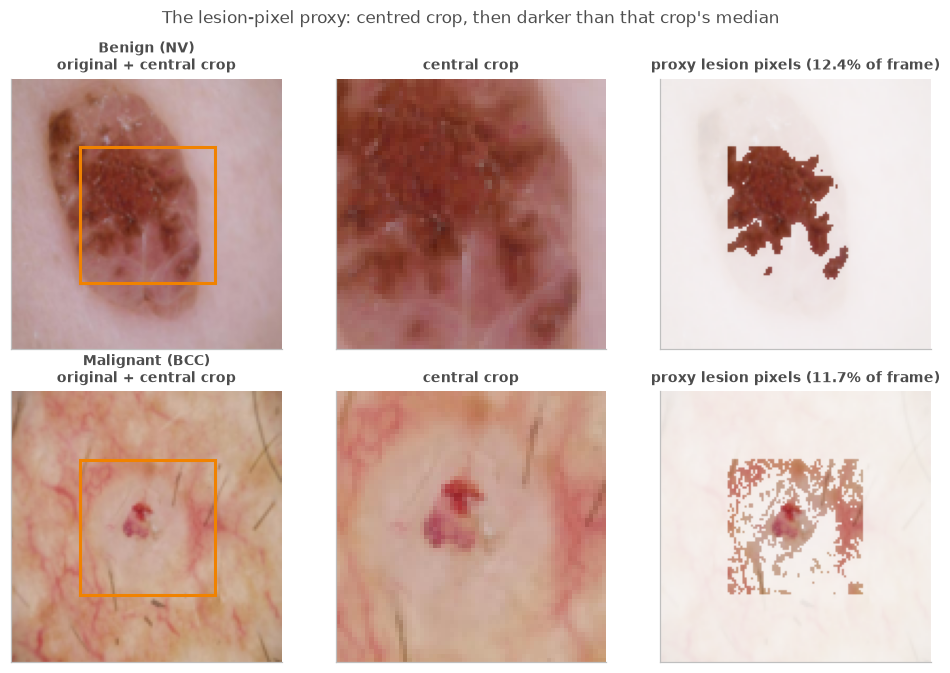

In [57]:
def lesion_proxy_mask(v: np.ndarray, crop_frac: float = CROP_FRAC) -> np.ndarray:
    """Boolean mask: darker-than-median pixels inside a centred crop of a V channel."""
    h, w = v.shape
    y0, y1 = int(h * (1 - crop_frac) / 2), int(h * (1 + crop_frac) / 2)
    x0, x1 = int(w * (1 - crop_frac) / 2), int(w * (1 + crop_frac) / 2)
    core = v[y0:y1, x0:x1]
    mask = np.zeros_like(v, dtype=bool)
    mask[y0:y1, x0:x1] = core < np.median(core)
    return mask


def circular_mean_deg(degrees) -> float:
    """Mean of angles: atan2(mean sin, mean cos), wrapped into [0, 360).

    Hue is an angle on a colour wheel, so the arithmetic mean is simply wrong: it averages a
    pinkish-red 355 deg and an orange-brown 5 deg to a cyan 180 deg, the opposite side of the
    wheel. Roughly a third of the lesion pixels here sit above 180 deg, so that is not a
    hypothetical failure mode on this dataset.
    """
    rad = np.deg2rad(np.asarray(degrees, dtype=float))
    return float(np.rad2deg(np.arctan2(np.sin(rad).mean(), np.cos(rad).mean())) % 360.0)


def circular_sd_deg(degrees) -> float:
    """Circular standard deviation, so a hue GAP can be read against hue SPREAD."""
    rad = np.deg2rad(np.asarray(degrees, dtype=float))
    resultant = np.hypot(np.sin(rad).mean(), np.cos(rad).mean())
    return float(np.rad2deg(np.sqrt(-2.0 * np.log(max(resultant, 1e-12)))))


def circular_diff_deg(a, b) -> float:
    """Signed a - b wrapped into (-180, 180]: the short way round the wheel."""
    return float((float(a) - float(b) + 180.0) % 360.0 - 180.0)


def hue_and_value(rgb_u8: np.ndarray, mask: np.ndarray) -> tuple[float, float]:
    """Circular-mean hue (degrees) and mean V over the masked pixels of one image."""
    hsv = rgb_to_hsv(rgb_u8.astype(np.float32) / 255.0)
    return circular_mean_deg(hsv[..., 0][mask] * 360.0), float(hsv[..., 2][mask].mean())


def working_image(isic_id: str) -> tuple[np.ndarray, Image.Image]:
    """One image at WORK_SIZE, as uint8 array and as PIL (ColorJitter needs PIL)."""
    # preprocess_image is the project's own resize, so the audit sees exactly the geometry
    # the training pipeline sees rather than a second, slightly different downscale.
    arr = preprocessing.preprocess_image(isic_id, size=WORK_SIZE, to_float=False)
    return arr, Image.fromarray(arr)


# --- Show the proxy on one lesion from each class --------------------------
examples = [sample[sample["diagnosis_1"] == g].iloc[0] for g in ("Benign", "Malignant")]
fig, axes = plt.subplots(2, 3, figsize=(9.0, 6.2))

for row, ex in zip(axes, examples):
    arr, _ = working_image(ex["isic_id"])
    hsv = rgb_to_hsv(arr.astype(np.float32) / 255.0)
    mask = lesion_proxy_mask(hsv[..., 2])
    lo, hi = int(WORK_SIZE * (1 - CROP_FRAC) / 2), int(WORK_SIZE * (1 + CROP_FRAC) / 2)

    # Rejected pixels are washed towards white so the kept ones read at a glance.
    dimmed = np.where(mask[..., None], arr,
                      0.82 * 255 + 0.18 * arr.astype(np.float32)).astype(np.uint8)

    row[0].imshow(arr)
    row[0].add_patch(plt.Rectangle((lo, lo), hi - lo, hi - lo, fill=False,
                                   edgecolor=config.ORANGE, linewidth=2))
    row[0].set_title(f"{ex['diagnosis_1']} ({ex['dx']})\noriginal + central crop", fontsize=9)
    row[1].imshow(arr[lo:hi, lo:hi])
    row[1].set_title("central crop", fontsize=9)
    row[2].imshow(dimmed)
    row[2].set_title(f"proxy lesion pixels ({mask.mean():.1%} of frame)", fontsize=9)
    for ax in row:
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

fig.suptitle("The lesion-pixel proxy: centred crop, then darker than that crop's median",
             fontsize=11)
plt.tight_layout()
plt.show()

### Measuring the class gap and the jitter-induced shift

Each image is measured once in its original state and once per jitter setting. Two details
make the numbers comparable rather than merely adjacent:

* the mask is computed **on the original image and then reused** for every jittered
  version. Re-deriving it after a brightness change would silently select a different set
  of pixels and mix a mask effect into the colour measurement;
* each jitter is applied at its **maximum** shift, not at a random draw, by passing a
  degenerate range to `ColorJitter` (`hue=(h, h)`, `brightness=(1-b, 1-b)`). For brightness
  we take the darkening end, because the brightening end clips at 255 and would understate
  the shift the transform can actually produce.

In [58]:
records = []
for isic_id, group in zip(sample["isic_id"], sample["diagnosis_1"]):
    arr, pil = working_image(isic_id)
    hsv = rgb_to_hsv(arr.astype(np.float32) / 255.0)
    mask = lesion_proxy_mask(hsv[..., 2])
    frame = np.ones_like(mask, dtype=bool)          # the control: the same stats, all pixels

    hue0, v0 = hue_and_value(arr, mask)
    hue0_f, v0_f = hue_and_value(arr, frame)
    rec = {"isic_id": isic_id, "group": group, "hue": hue0, "v": v0,
           "hue_frame": hue0_f, "v_frame": v0_f, "mask_frac": float(mask.mean())}

    for h in HUE_SETTINGS:
        jittered = np.asarray(transforms.colorjitter_probe(pil, hue=(h, h)))
        hue1, v1 = hue_and_value(jittered, mask)
        rec[f"hue={h:g}|dhue"] = abs(circular_diff_deg(hue1, hue0))
        rec[f"hue={h:g}|dv"] = abs(v1 - v0)

    for b in BRIGHTNESS_SETTINGS:
        jittered = np.asarray(transforms.colorjitter_probe(pil, brightness=(1 - b, 1 - b)))
        hue1, v1 = hue_and_value(jittered, mask)
        rec[f"brightness={b:g}|dhue"] = abs(circular_diff_deg(hue1, hue0))
        rec[f"brightness={b:g}|dv"] = abs(v1 - v0)

    records.append(rec)

per_image = pd.DataFrame(records)


def group_summary(hue_col: str, v_col: str) -> pd.DataFrame:
    """Per-class mean and spread of the two statistics, for one pixel definition."""
    return pd.DataFrame([
        {"group": g, "n": len(sub),
         "mean hue (deg)": circular_mean_deg(sub[hue_col]),
         "hue sd (deg)": circular_sd_deg(sub[hue_col]),
         "mean V": sub[v_col].mean(), "V sd": sub[v_col].std()}
        for g, sub in per_image.groupby("group")
    ])


print("proxy lesion pixels")
print(group_summary("hue", "v").round(3).to_string(index=False))
print("\nwhole frame (control)")
print(group_summary("hue_frame", "v_frame").round(3).to_string(index=False))

ben = per_image[per_image["group"] == "Benign"]
mal = per_image[per_image["group"] == "Malignant"]


def class_gap(hue_col: str, v_col: str) -> tuple[float, float]:
    """|Benign - Malignant| in circular-mean hue (deg) and in mean V."""
    return (abs(circular_diff_deg(circular_mean_deg(ben[hue_col]),
                                  circular_mean_deg(mal[hue_col]))),
            abs(float(ben[v_col].mean() - mal[v_col].mean())))


GAP_HUE, GAP_V = class_gap("hue", "v")
GAP_HUE_F, GAP_V_F = class_gap("hue_frame", "v_frame")
print(f"\nclass gap, proxy lesion pixels: hue {GAP_HUE:6.2f} deg   V {GAP_V:.4f}")
print(f"class gap, whole frame        : hue {GAP_HUE_F:6.2f} deg   V {GAP_V_F:.4f}")
print(f"mean proxy mask size          : {100 * per_image['mask_frac'].mean():.1f}% of the frame")

proxy lesion pixels
    group   n  mean hue (deg)  hue sd (deg)  mean V  V sd
   Benign 100         359.897         28.87   0.512 0.158
Malignant 100           0.441         19.26   0.654 0.119

whole frame (control)
    group   n  mean hue (deg)  hue sd (deg)  mean V  V sd
   Benign 100         349.476        26.072   0.646 0.099
Malignant 100         359.700        26.710   0.685 0.092

class gap, proxy lesion pixels: hue   0.54 deg   V 0.1420
class gap, whole frame        : hue  10.22 deg   V 0.0398
mean proxy mask size          : 11.9% of the frame


The two pixel definitions disagree sharply, which is the first real finding and the reason
both are carried through the table below. Before reading it, one check that the instrument
works: a `hue=h` jitter shifts every pixel by exactly `h * 360` degrees, and a
`brightness=b` jitter at its darkening end multiplies V by `1-b`, so the measured shifts
have to land on those numbers. Both are asserted rather than eyeballed.

In [59]:
rows = []
for h in HUE_SETTINGS:
    dh = per_image[f"hue={h:g}|dhue"].mean()
    rows.append({"transform": f"ColorJitter hue={h:g}", "nominal": f"{h * 360:.1f} deg",
                 "d hue (deg)": dh, "d V": per_image[f"hue={h:g}|dv"].mean(),
                 "x gap (proxy)": dh / GAP_HUE, "x gap (frame)": dh / GAP_HUE_F})
    # torchvision's 8-bit HSV round trip loses a little of the shift, but not much.
    assert abs(dh - h * 360) < 0.25 * h * 360, f"hue={h} moved {dh:.2f} deg, expected ~{h * 360:.1f}"

mean_v = per_image["v"].mean()
for b in BRIGHTNESS_SETTINGS:
    dv = per_image[f"brightness={b:g}|dv"].mean()
    rows.append({"transform": f"ColorJitter brightness={b:g}"
                              + ("  <- project setting" if b == 0.20 else ""),
                 "nominal": f"{b * mean_v:.3f} V",
                 "d hue (deg)": per_image[f"brightness={b:g}|dhue"].mean(), "d V": dv,
                 "x gap (proxy)": dv / GAP_V, "x gap (frame)": dv / GAP_V_F})
    assert abs(dv - b * mean_v) < 0.15 * b * mean_v, f"brightness={b} moved V by {dv:.3f}"

gaps = [
    {"transform": "class gap: proxy lesion pixels", "nominal": "measured",
     "d hue (deg)": GAP_HUE, "d V": GAP_V, "x gap (proxy)": 1.0, "x gap (frame)": np.nan},
    {"transform": "class gap: whole frame (control)", "nominal": "measured",
     "d hue (deg)": GAP_HUE_F, "d V": GAP_V_F, "x gap (proxy)": np.nan, "x gap (frame)": 1.0},
]
audit = pd.DataFrame([*gaps, *rows])

# The ratio columns already use the channel each knob actually moves, so the verdict is
# just how many of the two definitions the setting exceeds.
over = (audit["x gap (proxy)"] > 1).astype(int) + (audit["x gap (frame)"] > 1).astype(int)
audit["exceeds"] = np.where(audit["nominal"] == "measured", "-",
                            np.select([over == 2, over == 1], ["both", "one"], "neither"))

print(audit.round({"d hue (deg)": 2, "d V": 4, "x gap (proxy)": 2, "x gap (frame)": 2})
           .to_string(index=False, na_rep=""))

                                     transform   nominal  d hue (deg)    d V  x gap (proxy)  x gap (frame) exceeds
                class gap: proxy lesion pixels  measured         0.54 0.1420           1.00                      -
              class gap: whole frame (control)  measured        10.22 0.0398                          1.00       -
                          ColorJitter hue=0.02   7.2 deg         6.30 0.0000          11.57           0.62     one
                          ColorJitter hue=0.05  18.0 deg        16.05 0.0000          29.50           1.57    both
                           ColorJitter hue=0.1  36.0 deg        34.25 0.0000          62.95           3.35    both
                           ColorJitter hue=0.5 180.0 deg       178.06 0.0000         327.30          17.42    both
                    ColorJitter brightness=0.1   0.058 V         0.03 0.0601           0.42           1.51     one
ColorJitter brightness=0.2  <- project setting   0.117 V         0.03 0.1182    

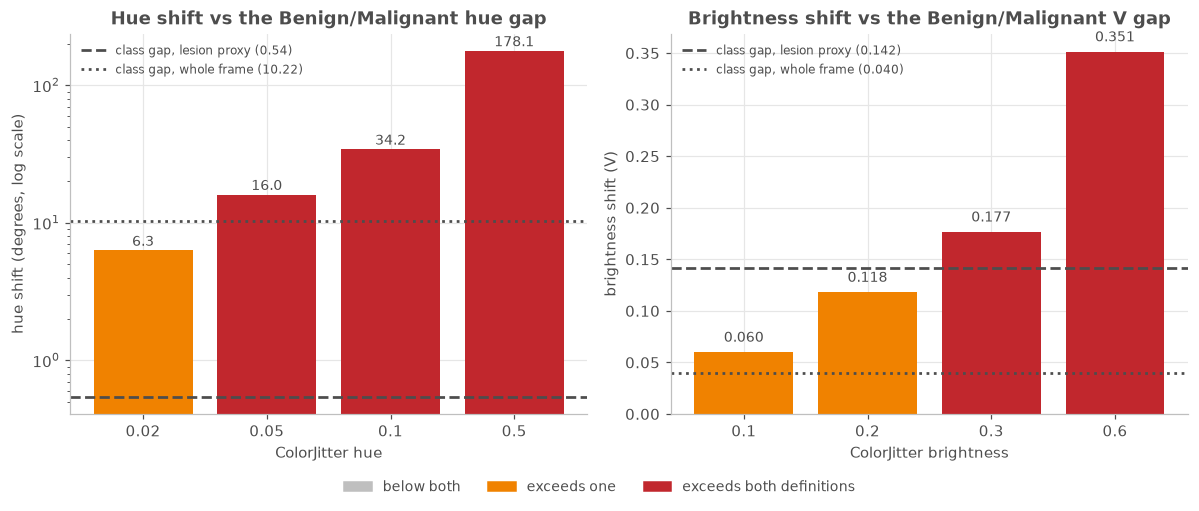

In [60]:
LEVELS = {2: ("exceeds both definitions", config.BENIGN_MALIGNANT_COLORS["Malignant"]),
          1: ("exceeds one", config.ORANGE),
          0: ("below both", "#BFBFBF")}

fig, (ax_h, ax_v) = plt.subplots(1, 2, figsize=(11, 4.4))

panels = [
    (ax_h, [f"{h:g}" for h in HUE_SETTINGS],
     [per_image[f"hue={h:g}|dhue"].mean() for h in HUE_SETTINGS],
     GAP_HUE, GAP_HUE_F, "ColorJitter hue", "hue shift (degrees, log scale)",
     "Hue shift vs the Benign/Malignant hue gap", "{:.1f}", "{:.2f}", True),
    (ax_v, [f"{b:g}" for b in BRIGHTNESS_SETTINGS],
     [per_image[f"brightness={b:g}|dv"].mean() for b in BRIGHTNESS_SETTINGS],
     GAP_V, GAP_V_F, "ColorJitter brightness", "brightness shift (V)",
     "Brightness shift vs the Benign/Malignant V gap", "{:.3f}", "{:.3f}", False),
]

for ax, names, values, gap_p, gap_f, xlabel, ylabel, title, fmt, gap_fmt, log in panels:
    levels = [int(x > gap_p) + int(x > gap_f) for x in values]
    ax.bar(names, values, color=[LEVELS[lv][1] for lv in levels])
    ax.axhline(gap_p, color=config.GREY, linestyle="--", linewidth=1.8,
               label=f"class gap, lesion proxy ({gap_fmt.format(gap_p)})")
    ax.axhline(gap_f, color=config.GREY, linestyle=":", linewidth=1.8,
               label=f"class gap, whole frame ({gap_fmt.format(gap_f)})")
    if log:
        ax.set_yscale("log")   # the bars span 6 to 178 degrees; linear would hide all but one
    for i, x in enumerate(values):
        ax.text(i, x * 1.08 if log else x + 0.01, fmt.format(x), ha="center", fontsize=9)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for _, (_, c) in sorted(LEVELS.items())]
fig.legend(handles, [LEVELS[k][0] for k in sorted(LEVELS)], loc="lower center",
           ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()

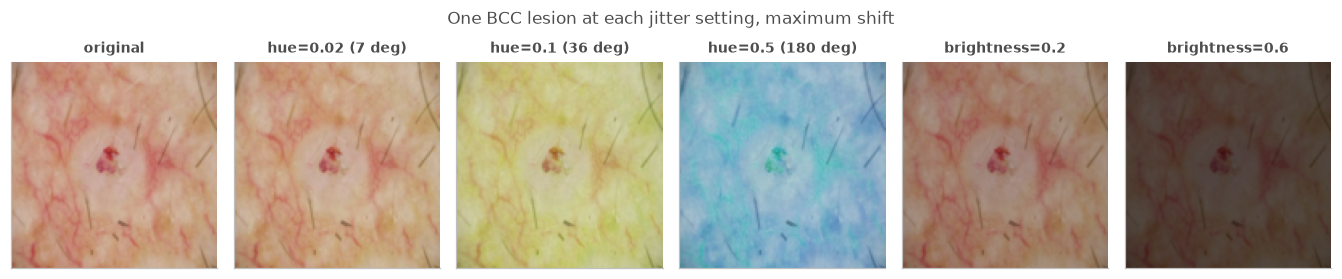

In [61]:
# What those degrees look like: the same lesion under each setting, so the table can be
# checked against an eye.
_, demo_pil = working_image(examples[1]["isic_id"])
strip = [("original", demo_pil)]
strip += [(f"hue={h:g} ({h * 360:.0f} deg)", transforms.colorjitter_probe(demo_pil, hue=(h, h)))
          for h in (0.02, 0.10, 0.50)]
strip += [(f"brightness={b:g}", transforms.colorjitter_probe(demo_pil, brightness=(1 - b, 1 - b)))
          for b in (0.20, 0.60)]

fig, axes = plt.subplots(1, len(strip), figsize=(2.05 * len(strip), 2.6))
for ax, (title, img) in zip(axes, strip):
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle(f"One {examples[1]['dx']} lesion at each jitter setting, maximum shift",
             fontsize=11)
plt.tight_layout()
plt.show()

**Answer (a) — which parameters change colour more than the class gap?** Measured on 100
Benign and 100 Malignant dermoscopic training images, over the proxy lesion pixels, the
classes sit **0.54 degrees apart in circular-mean hue** and **0.142 apart in mean V**. On
that yardstick **all four hue settings exceed the gap** — 0.02 shifts hue by 6.30 degrees
(11.57x the gap), 0.05 by 16.05 (29.50x), 0.1 by 34.25 (62.95x), 0.5 by 178.06 (327.30x) —
while for brightness
**0.3 (0.177 V, 1.24x) and 0.6 (0.351 V, 2.47x) exceed it** and 0.1 (0.060 V, 0.42x) and
0.2 (0.118 V, 0.83x) stay under.

That is not the expected result for hue, and the reason is worth stating plainly: the hue
gap is essentially zero. Benign lesions average 359.9 degrees and Malignant 0.4 degrees —
both classes are red — so "bigger than the hue gap" is a test that any non-zero hue jitter
passes and that therefore certifies nothing. Mean lesion hue does not separate these
classes at all. That negative result is still useful twice over: it says a model cannot be
taking a shortcut on average lesion hue, and it warns that a near-zero denominator makes
the ratio column meaningless on its own.

**The proxy changes the answer, so both definitions are reported.** On the whole frame the
gaps are 10.22 degrees and 0.0398 V — the hue gap is 19x larger and the V gap 3.6x smaller
than on the proxy pixels. Under that definition the verdicts flip: hue=0.02 falls *below*
the gap (0.62x) while brightness=0.1 and 0.2 rise *above* it (1.51x and 2.97x). **No tested
setting is below the class gap under both definitions.** Without a real segmentation mask
this audit can bound the risk but cannot settle it, and that limitation is a finding rather
than a failure — it is exactly why the decision belongs to a clinician.

**A sturdier yardstick, and the consequence for `train_transform` (hue=0.02,
brightness=0.2).** A difference of means over 100 images is fragile; the within-class
spread is not. Per-image hue varies with a circular sd of 28.9 degrees (Benign) and 19.3
(Malignant), and per-image mean V with an sd of 0.158 and 0.119. Against that, hue=0.02's
6.30 degrees is between a fifth and a third of the natural within-class variation and is
defensible — it is also the size of drift a different dermatoscope's white balance would
produce — whereas hue=0.1
(34.25 degrees) exceeds the spread of both classes and hue=0.5 (178.06 degrees) rotates a
red lesion to cyan, as the strip above shows. So the measurements **support hue=0.02** and
rule out the torchvision-tutorial default of 0.5 outright. They do **not** comfortably
support brightness=0.2: its 0.1182 shift is 83% of the entire proxy class gap, 2.97x the
whole-frame gap, and 0.75 to 0.99 of a within-class standard deviation (0.158 Benign, 0.119
Malignant), which means a single augmented image can be shifted about as far as a typical
Benign/Malignant brightness difference. **Tighten brightness
from 0.2 to 0.1**; even 0.1 stays above the whole-frame gap, so the residual risk is a
question for a clinician rather than for another parameter sweep. *This recommendation
was acted on:* `transforms.JITTER_BRIGHTNESS` is now 0.1, so the pipeline follows its own
audit. The 0.2 row above is kept because it is the setting the audit rejected.

**Answer (b).** The geometric augmentations are safe here — horizontal and vertical flips,
rotation, and mild scale or crop — because a dermatoscope is applied at whatever angle is
convenient and skin has no canonical "up", so every transformed image is one that could
genuinely have been captured; that is a domain-specific ruling and not a universal one,
since a vertical flip of a chest X-ray produces an anatomically impossible image. Anything
touching colour is risky, and so is aggressive cropping: pigmentation, erythema and the
blue-white veil are diagnostic criteria in their own right, a hue shift large enough to
move a lesion across the class colour gap has changed the label while leaving the filename
alone, and a hard crop can cut off the lesion border, which is half of the ABCD rule. The
audit above is why the colour knobs sit where they do rather than at library defaults, and
it says the brightness setting is the one running closest to its limit and should come
down. Approval is not an engineering call: every augmentation asserts that a transformation
never changes the diagnosis, which is a medical claim, so a dermatologist or
dermatopathologist has to sign it off. The engineer's job is the one done here — quantify
the shift in the same units as the real class difference, and be explicit about what the
measurement cannot settle — so that the clinician rules on a number instead of a vibe, and
so the choice is still auditable after everyone who made it has left the project.

## A3.6 A lesion-level `Dataset`

The training loop consumes one *image* at a time, but the label, the split and
the clinical decision all live at *lesion* grain. Two pieces of
`milk10k.datasets` bridge that gap and this section tests both of them:
`LesionDataset`, which serves both photographs of one lesion as a single item,
and `aggregate_predictions`, which folds two per-image probability vectors back
into one prediction per lesion.

Every claim below is asserted in code, so the section fails loudly instead of
printing a plausible-looking number.

In [62]:
import time
from collections import Counter

import torch
from torch.utils.data import DataLoader

from milk10k import datasets

transforms.seed_everything(config.SEED)

lesion_table = data.build_lesion_table()
LABEL_COL = config.PRIMARY_LABEL_COL

print(f"lesion table : {len(lesion_table):,} rows x {lesion_table.shape[1]} columns")
print(lesion_table.head(3).to_string(index=False))

lesion table : 5,240 rows x 8 columns
 lesion_id      derm_id  clinical_id diagnosis_1  dx  age    sex            site
IL_0000652 ISIC_4671410 ISIC_8149219   Malignant BCC 70.0   male       head/neck
IL_0003176 ISIC_5371928 ISIC_3904045   Malignant BCC 45.0 female       head/neck
IL_0004688 ISIC_3624913 ISIC_0791494   Malignant BCC 50.0   male lower extremity


### (a) One batch, and the three things that can silently go wrong

A batch that is the right *shape* can still be wrong. The three failures worth
guarding against are: the ids drifting away from the labels (you would only
notice in the confusion matrix), a missing file being skipped instead of
raised (the dataset silently shrinks), and the two views sharing one draw of
the augmentation (the two-view branch sees half the diversity it should).

In [63]:
BATCH = 8
batch_table = lesion_table.head(BATCH * 2).reset_index(drop=True)

# The full signature the brief specifies: (lesion_table, img_dir, label_col, transform, views).
eval_ds = datasets.LesionDataset(
    batch_table, img_dir=config.IMG_DIR, label_col=LABEL_COL,
    transform=transforms.eval_transform(), views=("derm", "clinical"),
)
loader = DataLoader(eval_ds, batch_size=BATCH, shuffle=False)
batch = next(iter(loader))

print("batch keys:", list(batch))
for view in eval_ds.views:
    tensor = batch[view]
    print(f"  {view:<10} {tuple(tensor.shape)}  {tensor.dtype}")
print(f"  {'label':<10} {tuple(batch['label'].shape)}  {batch['label'].dtype}")
print(f"  {'lesion_id':<10} list of {len(batch['lesion_id'])} str")
print("\nlabel tensor :", batch["label"])
print("class names  :", [eval_ds.inverse_label_map[i] for i in batch["label"].tolist()])
print("lesion ids   :", list(batch["lesion_id"]))

expected_shape = (BATCH, 3, config.IMAGE_SIZE, config.IMAGE_SIZE)
for view in eval_ds.views:
    assert tuple(batch[view].shape) == expected_shape, (
        f"{view}: got {tuple(batch[view].shape)}, expected {expected_shape}"
    )
    assert batch[view].dtype is torch.float32, f"{view} is not float32"

# The ids and the labels must come from the SAME rows of the table, in order --
# a shuffled or off-by-one id column is invisible until error analysis.
expected_ids = batch_table["lesion_id"].head(BATCH).tolist()
expected_labels = [eval_ds.label_map[v] for v in batch_table[LABEL_COL].head(BATCH)]
assert list(batch["lesion_id"]) == expected_ids, "lesion_ids do not match the table"
assert batch["label"].tolist() == expected_labels, "labels do not match the table"
print("\nshapes, ids and labels all match the lesion table.")

batch keys: ['derm', 'clinical', 'label', 'lesion_id']
  derm       (8, 3, 224, 224)  torch.float32
  clinical   (8, 3, 224, 224)  torch.float32
  label      (8,)  torch.int64
  lesion_id  list of 8 str

label tensor : tensor([2, 2, 2, 2, 2, 2, 0, 2])
class names  : ['Malignant', 'Malignant', 'Malignant', 'Malignant', 'Malignant', 'Malignant', 'Benign', 'Malignant']
lesion ids   : ['IL_0000652', 'IL_0003176', 'IL_0004688', 'IL_0005081', 'IL_0006177', 'IL_0006407', 'IL_0008891', 'IL_0008969']

shapes, ids and labels all match the lesion table.


In [64]:
# A missing file must crash, not be skipped: a dataset that quietly loses rows
# changes the denominator of every metric without telling anyone.
BOGUS_ID = "ISIC_0000000"
assert not (config.IMG_DIR / f"{BOGUS_ID}.jpg").exists(), "pick an id that really is absent"

bogus_table = lesion_table.head(1).copy()
bogus_table["derm_id"] = BOGUS_ID
bogus_ds = datasets.LesionDataset(
    bogus_table, label_col=LABEL_COL, transform=transforms.eval_transform()
)

try:
    bogus_ds[0]
except FileNotFoundError as exc:
    message = str(exc)
    assert BOGUS_ID in message, "the error does not name the offending id"
    print("FileNotFoundError raised, and it names the id:")
    print(" ", message.split(". ")[0])
else:
    raise AssertionError("a missing image file did not raise FileNotFoundError")

FileNotFoundError raised, and it names the id:
  LesionDataset lesion 'IL_0000652' view 'derm': no image file for isic_id 'ISIC_0000000': expected /Users/stanislauslattorff/Desktop/Computer_Vision/data/milk10k/images/ISIC_0000000.jpg


In [65]:
# Is the transform drawn independently per view? Asking a real lesion is not a
# test -- its two tensors differ because they are two different photographs. So
# request the SAME photograph as both views: any difference that survives is
# then purely the randomness of the augmentation.
same_photo = lesion_table.head(1).copy()
same_photo["clinical_id"] = same_photo["derm_id"]

deterministic = datasets.LesionDataset(
    same_photo, label_col=LABEL_COL, transform=transforms.eval_transform()
)[0]
assert torch.equal(deterministic["derm"], deterministic["clinical"]), (
    "eval_transform is not deterministic"
)

transforms.seed_everything(config.SEED)
augmented = datasets.LesionDataset(
    same_photo, label_col=LABEL_COL, transform=transforms.train_transform()
)[0]
gap = (augmented["derm"] - augmented["clinical"]).abs().max().item()
assert not torch.equal(augmented["derm"], augmented["clinical"]), (
    "train_transform produced identical tensors for two independent draws"
)

real_lesion = datasets.LesionDataset(
    lesion_table.head(1), label_col=LABEL_COL, transform=transforms.train_transform()
)[0]
assert not torch.equal(real_lesion["derm"], real_lesion["clinical"])

print(f"same photograph, eval_transform  : tensors identical  ({config.IMAGE_SIZE}px, deterministic)")
print(f"same photograph, train_transform : tensors differ, max |diff| = {gap:.3f}")
print("real lesion,    train_transform : tensors differ (two photographs AND two draws)")

same photograph, eval_transform  : tensors identical  (224px, deterministic)
same photograph, train_transform : tensors differ, max |diff| = 2.597
real lesion,    train_transform : tensors differ (two photographs AND two draws)


**What (a) shows.** The batch is `(8, 3, 224, 224)` per view with `float32`
tensors, an `int64` label tensor and a list of 8 ids, and ids and labels are
row-aligned with the lesion table. A missing file raises `FileNotFoundError`
naming the id. The transform fires once per view: feeding the *same*
photograph in as both views gives identical tensors under `eval_transform` and
different ones under `train_transform`. Independent application is the correct
choice here because the dermoscopic and clinical images are two different
photographs of the lesion, taken with different instruments at different
magnifications — forcing them to share a rotation or crop would assert a
geometric correspondence between them that does not exist.

### (b) One epoch over 800 lesions

The check that matters for a training loop is conservation: after a full pass
with shuffling, the class counts the loader handed out must equal the class
counts of the table it was built from. Anything else means rows were dropped,
repeated or relabelled somewhere between the CSV and the batch.

In [66]:
N_LESIONS = 800
subset = lesion_table.sample(n=N_LESIONS, random_state=config.SEED).reset_index(drop=True)

epoch_ds = datasets.LesionDataset(
    subset, label_col=LABEL_COL, transform=transforms.eval_transform()
)
n_workers = datasets.default_num_workers()
generator = torch.Generator()
generator.manual_seed(config.SEED)
epoch_loader = DataLoader(
    epoch_ds, batch_size=16, shuffle=True, num_workers=n_workers, generator=generator
)

seen_counts: Counter = Counter()
seen_ids: list[str] = []
started = time.perf_counter()
for epoch_batch in epoch_loader:
    for code in epoch_batch["label"].tolist():
        seen_counts[epoch_ds.inverse_label_map[code]] += 1
    seen_ids.extend(epoch_batch["lesion_id"])
elapsed = time.perf_counter() - started

n_images = len(seen_ids) * len(epoch_ds.views)
print(
    f"one epoch: {len(seen_ids):,} lesions = {n_images:,} image decodes in "
    f"{elapsed:.1f}s  ({n_images / elapsed:.0f} img/s, num_workers={n_workers})"
)

comparison = pd.DataFrame(
    {"table": subset[LABEL_COL].value_counts(), "loader": pd.Series(seen_counts)}
).fillna(0).astype(int).sort_index()
comparison.index.name = "class"
print()
print(comparison.to_string())

assert len(seen_ids) == N_LESIONS, f"saw {len(seen_ids)} lesions, expected {N_LESIONS}"
assert sorted(seen_ids) == sorted(subset["lesion_id"]), (
    "the epoch did not visit each lesion exactly once"
)
assert comparison["table"].equals(comparison["loader"]), (
    "class counts seen by the loader differ from the subset's own counts"
)
print("\nevery lesion seen exactly once; class counts match the subset exactly.")

one epoch: 800 lesions = 1,600 image decodes in 3.4s  (471 img/s, num_workers=0)

               table  loader
class                       
Benign           207     207
Indeterminate     22      22
Malignant        571     571

every lesion seen exactly once; class counts match the subset exactly.


**What (b) shows.** Shuffling changes the order of an epoch and nothing else:
all 800 lesions appear exactly once and the three class counts are identical
to the subset's. `default_num_workers()` returns 0 on macOS on purpose —
worker processes are started with `spawn`, which re-imports the entry module
and hangs inside a Jupyter kernel — so the decoding happens in the main
process, and the timing above is the honest floor under a training epoch on
this machine.

### (c) Two views in, one prediction out

`aggregate_predictions` averages a lesion's per-image probability vectors.
Testing it on real model output would only tell us the model's opinion, so the
probabilities here are synthetic and the right answer is computed by hand
first. Three cases: the two views agree, the two views disagree so that the
average flips the argmax away from the dermoscopic view, and a lesion with
only one view present.

In [67]:
CLASSES = list(config.PRIMARY_LABELS)  # index == the integer label, from labels.py

synthetic_images = pd.DataFrame(
    {
        "isic_id": ["IMG_A_d", "IMG_A_c", "IMG_B_d", "IMG_B_c", "IMG_C_d"],
        "lesion_id": ["LES_AGREE", "LES_AGREE", "LES_FLIP", "LES_FLIP", "LES_ONE_VIEW"],
        "view": ["derm", "clinical", "derm", "clinical", "derm"],
    }
)
#                              Benign  Indeterminate  Malignant
synthetic_probs = np.array(
    [
        [0.05, 0.05, 0.90],  # LES_AGREE    derm      -> Malignant
        [0.10, 0.10, 0.80],  # LES_AGREE    clinical  -> Malignant
        [0.60, 0.05, 0.35],  # LES_FLIP     derm      -> Benign, mildly wrong
        [0.02, 0.03, 0.95],  # LES_FLIP     clinical  -> Malignant, confidently right
        [0.05, 0.90, 0.05],  # LES_ONE_VIEW derm      -> Indeterminate, no second view
    ]
)

per_image_pred = [CLASSES[i] for i in synthetic_probs.argmax(axis=1)]
print("per-image argmax:", dict(zip(synthetic_images["isic_id"], per_image_pred)))

lesion_pred = datasets.aggregate_predictions(
    synthetic_probs, synthetic_images, class_names=CLASSES
)
print()
print(lesion_pred.to_string(index=False))

per-image argmax: {'IMG_A_d': 'Malignant', 'IMG_A_c': 'Malignant', 'IMG_B_d': 'Benign', 'IMG_B_c': 'Malignant', 'IMG_C_d': 'Indeterminate'}

   lesion_id  n_views  Benign  Indeterminate  Malignant  pred_index          pred
   LES_AGREE        2   0.075          0.075       0.85           2     Malignant
    LES_FLIP        2   0.310          0.040       0.65           2     Malignant
LES_ONE_VIEW        1   0.050          0.900       0.05           1 Indeterminate


In [68]:
# Hand-computed expectations. These are the arithmetic means of the rows above;
# writing them out literally is the whole point -- an expectation derived with
# the same code being tested would pass no matter what that code did.
expected_probs = np.array(
    [
        [0.075, 0.075, 0.850],  # LES_AGREE     (0.05+0.10)/2, (0.05+0.10)/2, (0.90+0.80)/2
        [0.310, 0.040, 0.650],  # LES_FLIP      (0.60+0.02)/2, (0.05+0.03)/2, (0.35+0.95)/2
        [0.050, 0.900, 0.050],  # LES_ONE_VIEW  single view, passed through unchanged
    ]
)
expected_pred = ["Malignant", "Malignant", "Indeterminate"]

assert lesion_pred["lesion_id"].tolist() == ["LES_AGREE", "LES_FLIP", "LES_ONE_VIEW"]
assert lesion_pred["n_views"].tolist() == [2, 2, 1]
assert np.allclose(lesion_pred[CLASSES].to_numpy(), expected_probs), (
    "averaged probabilities differ from the hand-computed values"
)
assert lesion_pred["pred"].tolist() == expected_pred
assert lesion_pred["pred_index"].tolist() == [CLASSES.index(p) for p in expected_pred]

# The point of LES_FLIP: the dermoscopic view alone would have called it Benign,
# and a hard vote over the two views is a 1-1 tie. Averaging the probabilities
# resolves it towards the confident view, which is the behaviour we want.
assert per_image_pred[2] == "Benign" and per_image_pred[3] == "Malignant"
assert lesion_pred.loc[1, "pred"] == "Malignant"
# A single-view lesion is averaged over what exists, i.e. left untouched.
assert np.allclose(lesion_pred.loc[2, CLASSES].to_numpy(dtype=float), synthetic_probs[4])

print("all three synthetic cases match the hand-computed answer:")
print("  LES_AGREE    both views Malignant            -> Malignant   (n_views=2)")
print("  LES_FLIP     derm Benign, clinical Malignant -> Malignant   (n_views=2, argmax flipped)")
print("  LES_ONE_VIEW one view only                   -> Indeterminate (n_views=1, unchanged)")

all three synthetic cases match the hand-computed answer:
  LES_AGREE    both views Malignant            -> Malignant   (n_views=2)
  LES_FLIP     derm Benign, clinical Malignant -> Malignant   (n_views=2, argmax flipped)
  LES_ONE_VIEW one view only                   -> Indeterminate (n_views=1, unchanged)


**What (c) shows.** The function returns one row per lesion with an `n_views`
column, so a half-observed lesion is visible in the results instead of looking
like a normal one. `LES_FLIP` is the case worth defending: the dermoscopic view
is mildly wrong (Benign at 0.60) and the clinical view confidently right
(Malignant at 0.95); a hard vote over the two labels is a 1–1 tie, while the
probability average lands at 0.65 Malignant and resolves towards the confident
view. That is why averaging probabilities beats voting on labels — the vote
throws away exactly the information that breaks the tie.

### (d) The unit of evaluation

**Answer.** The lesion is the unit of evaluation: it is the object the clinical
decision is about, and the two photographs are two views of one lesion, not two
independent cases. Scoring per image double-counts every lesion, so the
effective sample size is half what the denominator claims and every confidence
interval comes out too narrow. It also hands out half credit for lesions the
model is inconsistent about — dermoscopic right and clinical wrong scores 50%
on a lesion whose real answer is "we do not know", which is not a clinical
outcome — and per-image scoring hides exactly the disagreement a clinician
would most want surfaced.